<a href="https://colab.research.google.com/github/TAUforPython/LLM_AI_agents/blob/main/lesson-7_Score_Agent_Answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluating Agents: From Theory to Practice

**Running example:** medical appointment agent on LangGraph

This notebook demonstrates the full cycle of building an eval system for an AI agent:

| Part | Topic | What we'll see |
|-------|------|------------|
| 1 | **Agent** | Medical assistant + 4 tools + policies |
| 2 | **Task basket** | 12 tasks (10 base + 2 extra-hard), balance visualization |
| 3 | **Criteria and graders** | Quality (LLM) + State (code) + Policy (code) |
| 4 | **Run v1** | Single-turn: showing the problems |
| 5 | **Iron User** | v1 (naive → looping) → v2 (improved) |
| 6 | **Human labeling** | Your labels → Quality Score → ground truth |
| 7 | **LLM-as-Judge** | v1→v2→v3→v4 + **scoreboard** (Quality Score + κ + Speed + Cost) |
| 8 | **Combining** | Combined score, final table |



# Part 1. Agent


We build a simple medical appointment assistant using **LangGraph ReAct** with 4 tools:

- `get_appointment` — look up an appointment by confirmation code
- `search_doctors` — search available doctors
- `reschedule_appointment` — change the appointment to a different time/day
- `cancel_appointment` — cancel an appointment

The agent records every step in a `Trajectory` for later evaluation.

---

In [ ]:
# ── Imports and environment setup ──
!pip install langchain langchain-openai langgraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.3/513.3 kB 9.4 MB/s eta 0:00:00


In [ ]:
import json, os, re, copy, time
from dataclasses import dataclass, field
from typing import List, Optional, Any
from collections import Counter
import httpx

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
!pip install langchain_mistralai -q

In [ ]:
MODEL_NAME = 'mistral-small-latest' # or "mistral-large-latest"

import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

In [ ]:
## §1. Setup & Infrastructure
#Environment, imports, connectivity test

# Some proxies wrap OpenAI JSON inside {"response": {...}} — unwrap transparently.
def _unwrap_proxy(response: httpx.Response) -> None:
    """Some proxies wrap the real OpenAI response inside a 'response' field.
    This hook transparently unwraps it so langchain sees standard format."""
    if response.status_code == 200:
        try:
            response.read()
            data = response.json()
            if isinstance(data, dict) and 'response' in data and isinstance(data['response'], dict):
                inner = data['response']
                response._content = json.dumps(inner).encode('utf-8')
        except Exception:
            pass

# Attach the hook so every ChatOpenAI HTTP call goes through the unwrapper.
HTTP_CLIENT_UNWRAP = httpx.Client(
    event_hooks={'response': [_unwrap_proxy]},
    verify=False,
)
# ---------------------------------------------------------------------

MODEL_NAME = 'mistral-small-latest' # or "mistral-large-latest"

import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

print(f"   Model:    {MODEL_NAME}")

# test_llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0, base_url=OPENAI_BASE_URL, max_tokens=5, http_client=HTTP_CLIENT_UNWRAP)
# test_resp = test_llm.invoke([HumanMessage(content="Say 'ok'")])
# assert test_resp.content, "LLM returned an empty response — check OPENAI_API_KEY and OPENAI_BASE_URL"
# print(f"\n✅ Connection works (response: {test_resp.content.strip()[:30]})")

"""---
## §2. Domain: Medical Database & Tools
DB schema, read/write operations, policies

"""

# DATABASE: in-memory mock environment — fresh_db() ensures each trial starts from a clean state

def fresh_db():
    """Fresh copy of the medical DB. Called before each run."""
    return {
        "doctors": {
            # doctor_key = id + date ("CARD-001_0220") — differs from 'id' field intentionally
            # to expose a common agent error: using id instead of doctor_key in reschedule_appointment
            "CARD-001_0220": {"id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown Clinic", "date": "2026-02-20", "time": "09:00", "duration": 45, "fee": 200, "available": True},
            "CARD-001_0220b": {"id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown Clinic", "date": "2026-02-20", "time": "14:00", "duration": 45, "fee": 200, "available": True},
            "PED-001_0220": {"id": "PED-001", "name": "Dr. James Wilson", "specialty": "Pediatrics", "location": "Children's Health Center", "date": "2026-02-20", "time": "10:00", "duration": 30, "fee": 120, "available": True},
            "PED-002_0220": {"id": "PED-002", "name": "Dr. Lisa Park", "specialty": "Pediatrics", "location": "Family Medicine Clinic", "date": "2026-02-20", "time": "11:30", "duration": 30, "fee": 100, "available": True},
            "DERM-001_0220": {"id": "DERM-001", "name": "Dr. Olivia Martinez", "specialty": "Dermatology", "location": "Skin Care Center", "date": "2026-02-20", "time": "15:00", "duration": 30, "fee": 160, "available": True},
            "GP-001_0220": {"id": "GP-001", "name": "Dr. Michael Chen", "specialty": "General Practice", "location": "Family Medicine Clinic", "date": "2026-02-20", "time": "08:30", "duration": 25, "fee": 100, "available": True},
            "CARD-001_0221": {"id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown Clinic", "date": "2026-02-21", "time": "09:00", "duration": 45, "fee": 190, "available": True},
            "PED-001_0221": {"id": "PED-001", "name": "Dr. James Wilson", "specialty": "Pediatrics", "location": "Children's Health Center", "date": "2026-02-21", "time": "10:00", "duration": 30, "fee": 115, "available": True},
        },
        "appointments": {
            "AP001": {"patient": "Ivan Petrov",    "doctor_key": "CARD-001_0220", "status": "confirmed", "reason": "routine checkup", "contact": "ivan@example.com"},
            "AP002": {"patient": "Maria Sidorova", "doctor_key": "PED-001_0220", "status": "confirmed", "reason": "vaccination", "contact": "maria@example.com"},
        },
    }

# deep copy, not reference — captures DB state before agent mutates it
def snapshot_db(db):
    """Deep copy of DB state — for before/after comparison."""
    return copy.deepcopy(db)

# READ-ONLY tools — agent's only way to perceive the environment (same code as production)

@tool
def get_appointment(appointment_id: str) -> str:
    """Get an appointment by ID."""
    a = DB["appointments"].get(appointment_id)
    if not a:
        return json.dumps({"error": f"Appointment {appointment_id} not found"})
    d = DB["doctors"].get(a["doctor_key"], {})
    return json.dumps({"appointment_id": appointment_id, **a, "doctor": d}, ensure_ascii=False)

@tool
def search_doctors(specialty: str, date: str, location: str = None) -> str:
    """Search for available doctors. specialty — medical specialty (Cardiology, Pediatrics, etc.). date — YYYY-MM-DD. location — optional clinic name."""
    # INTENTIONAL BUG v1: returns 'id' but not 'doctor_key' — agent can't call reschedule_appointment correctly.
    # This triggers the cascade-error demo in Iron User v1 (see Part 5). Fixed in v2.
    results = [d for d in DB["doctors"].values()
               if d["specialty"].lower() == specialty.lower() and d["date"] == date and d["available"]]
    if location:
        results = [d for d in results if location.lower() in d["location"].lower()]
    return json.dumps(sorted(results, key=lambda x: x["time"]), ensure_ascii=False)

# WRITE tools — mutate DB in place; state_grader checks these mutations after the run
@tool
def reschedule_appointment(appointment_id: str, new_doctor_key: str) -> str:
    """Reschedule an appointment to a different time/day. new_doctor_key — doctor key, e.g. CARD-001_0220."""
    a = DB["appointments"].get(appointment_id)
    if not a:
        return json.dumps({"error": "Appointment not found"})
    nd = DB["doctors"].get(new_doctor_key)
    if not nd:
        return json.dumps({"error": "Doctor slot not found"})
    if not nd["available"]:
        return json.dumps({"error": "Slot not available"})
    old_d = DB["doctors"].get(a["doctor_key"], {})
    diff = nd["fee"] - old_d.get("fee", 0)
    a["doctor_key"], a["status"] = new_doctor_key, "rescheduled"
    nd["available"] = False
    old_d["available"] = True
    return json.dumps({"success": True, "new_doctor": nd["name"], "fee_diff": diff}, ensure_ascii=False)

@tool
def cancel_appointment(appointment_id: str) -> str:
    """Cancel an appointment."""
    a = DB["appointments"].get(appointment_id)
    if not a:
        return json.dumps({"error": "Appointment not found"})
    d = DB["doctors"].get(a["doctor_key"])
    a["status"] = "cancelled"
    if d:
        d["available"] = True
    return json.dumps({"success": True, "refund": d["fee"] if d else 0}, ensure_ascii=False)

TOOLS = [get_appointment, search_doctors, reschedule_appointment, cancel_appointment]

# POLICIES are part of the environment (like τ-bench "wiki/rules"): versioned alongside the DB,
# inlined into SYSTEM_PROMPT for the agent, and checked post-run by policy_grader
POLICIES = [
    "Request confirmation before any appointment change or cancellation",
    "Retrieve the current appointment first, then suggest changes",
    "Report the fee difference when rescheduling",
    "Do not disclose other patients' data",
    "If information is insufficient — ask the patient",
]

DB = fresh_db()
print(f"✅ DB and tools ready")
print(f"   Doctors: {len(DB['doctors'])}, Appointments: {len(DB['appointments'])}")
print(f"   Tools:  {[t.name for t in TOOLS]}")
print(f"   Policies: {len(POLICIES)} rules")

"""---
## §3. Agent Architecture
Data models (Step, Trajectory), ReAct pattern, execution

"""

# Step — atomic unit of a trajectory (лекция: траектория = sequence of steps)

@dataclass
class Step:
    # 'action'=tool call | 'observation'=tool result | 'response'=final text to user
    type: str
    content: Any

# Trajectory — full record of one trial (прогон): steps + DB snapshots for grading

@dataclass
class Trajectory:
    task_id: str
    query: str
    steps: List[Step] = field(default_factory=list)
    final_response: str = ""
    # db_before/db_after: captured by run_agent — state_grader diffs them
    # (key principle: evaluate by env state change, not by text of the response)
    db_before: Optional[dict] = field(default=None, repr=False)
    db_after: Optional[dict] = field(default=None, repr=False)

    def show(self):
        print(f"{'─'*60}\n📋 {self.task_id}: {self.query}")
        for s in self.steps:
            icons = {"action": "🔧", "observation": "👁", "response": "💬"}
            txt = s.content if isinstance(s.content, str) else json.dumps(s.content, ensure_ascii=False)
            print(f"  {icons.get(s.type, '?')} {txt[:200]}")
        print()

    def as_text(self) -> str:
        # flattens all steps into a single string — used as input for LLM Judge
        lines = []
        for s in self.steps:
            txt = s.content if isinstance(s.content, str) else json.dumps(s.content, ensure_ascii=False)
            lines.append(f"[{s.type}] {txt[:500]}")
        return "\n".join(lines)

# SYSTEM_PROMPT — agent's "constitution": same prompt in eval and production

SYSTEM_PROMPT = (
    "You are a virtual medical appointment assistant. Reply in English.\n"
    # Explicit date prevents LLM from defaulting to training year — see task t02
    "Today: February 20, 2026 (2026-02-20).\n\n"
    "Available tools:\n"
    "- get_appointment(appointment_id) — get an appointment\n"
    "- search_doctors(specialty, date, location) — search for doctors (specialties: Cardiology, Pediatrics, Dermatology, General Practice; date: YYYY-MM-DD; location: optional)\n"
    "- reschedule_appointment(appointment_id, new_doctor_key) — reschedule an appointment (doctor key: e.g. CARD-001_0220)\n"
    "- cancel_appointment(appointment_id) — cancel an appointment\n\n"
    "Rules (MUST be followed):\n"
    + "\n".join(f"{i+1}. {p}" for i, p in enumerate(POLICIES))
)

# ReAct agent (Reasoning + Acting): LLM alternates between calling tools and responding
# Each tool call = one "action" step in the trajectory; repeated calls inflate the efficiency score

def _build_react_agent(llm, tools):
    """Build a ReAct agent graph using StateGraph (LangGraph 1.0+)."""
    tool_node = ToolNode(tools)
    # bind_tools: registers tool schemas so the LLM knows when and how to call them
    llm_with_tools = llm.bind_tools(tools)

    def call_model(state: MessagesState):
        response = llm_with_tools.invoke(state["messages"])
        return {"messages": [response]}

    builder = StateGraph(MessagesState)
    builder.add_node("agent", call_model)
    builder.add_node("tools", tool_node)
    builder.set_entry_point("agent")
    # tools_condition: if response contains tool_calls → go to "tools", else → END
    builder.add_conditional_edges("agent", tools_condition)
    builder.add_edge("tools", "agent")
    return builder.compile()

# llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.1, base_url=OPENAI_BASE_URL, http_client=HTTP_CLIENT_UNWRAP)
agent_graph = _build_react_agent(llm, TOOLS)

# run_agent: Runner + Logger — executes the agent and records the full trajectory

def run_agent(query: str, task_id: str = "", messages: list = None) -> tuple:
    """Runs the agent, returns (Trajectory, messages). Saves DB snapshots."""
    global DB
    # snapshot before run — state_grader will compare db_before vs db_after
    db_before = snapshot_db(DB)
    t = Trajectory(task_id=task_id, query=query, db_before=db_before)

    if messages is None:
        messages = [SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=query)]

    result = agent_graph.invoke({"messages": messages})

    for msg in result["messages"]:
        if isinstance(msg, AIMessage):
            if msg.tool_calls:
                for tc in msg.tool_calls:
                    t.steps.append(Step("action", {"tool": tc["name"], "args": tc["args"]}))
            elif msg.content:
                t.steps.append(Step("response", msg.content))
                t.final_response = msg.content
        elif isinstance(msg, ToolMessage):
            t.steps.append(Step("observation", msg.content[:500]))

    # snapshot after run — records all DB mutations made by reschedule/cancel tools
    t.db_after = snapshot_db(DB)
    return t, result["messages"]

# ── Demo: single-turn test (appointment lookup) ──

DB = fresh_db()
t_demo, _ = run_agent("Show information about appointment AP001", task_id="demo")
t_demo.show()
print("DB state unchanged:", t_demo.db_before == t_demo.db_after)

"""---"""

   Model:    mistral-small-latest
✅ DB and tools ready
   Doctors: 8, Appointments: 2
   Tools:  ['get_appointment', 'search_doctors', 'reschedule_appointment', 'cancel_appointment']
   Policies: 5 rules
────────────────────────────────────────────────────────────
📋 demo: Show information about appointment AP001
  🔧 {"tool": "get_appointment", "args": {"appointment_id": "AP001"}}
  👁 {"appointment_id": "AP001", "patient": "Ivan Petrov", "doctor_key": "CARD-001_0220", "status": "confirmed", "reason": "routine checkup", "contact": "ivan@example.com", "doctor": {"id": "CARD-001", "na
  💬 Here is the information for your appointment:

- **Appointment ID:** AP001
- **Patient:** Ivan Petrov
- **Doctor:** Dr. Sarah Johnson
- **Specialty:** Cardiology
- **Location:** Downtown Clinic
- **Da

DB state unchanged: True


'---'


# Part 2. Task Basket

A good task basket: diverse scenarios, varying difficulty, edge cases included, well-balanced.

**Task format** (extended compared to the classic format):
- `query` — user request
- `expected_state_changes` — what should change in the DB (for state-based grading)
- `policies_to_check` — which policies are especially important for this task
- `category`, `difficulty`, `needs_dialogue` — metadata for analysis


=== Task basket: 12 tasks ===

By category:  {'info': 2, 'search': 2, 'change': 4, 'cancel': 2, 'edge': 2}
By difficulty:   {'easy': 3, 'medium': 4, 'hard': 3, 'extra_hard': 2}
Needs dialogue:   7/12
With state check: 5/12

  [E] t01: Show information about appointment AP001                     
  [E] t02: Find Cardiology doctors available on February 20             
  [E] t03: What is the status of appointment AP002?                     
  [M] t04: I want to reschedule appointment AP001 to a later time  📊 💬
  [M] t05: Cancel my appointment AP001                             📊 💬
  [M] t06: Find Cardiology doctors and compare with Pediatrics on       
  [M] t07: Reschedule appointment AP001 to the afternoon appointme 📊 💬
  [H] t08: Move AP001 to tomorrow, but only if it will be cheaper  📊 💬
  [H] t09: Show appointment FAKE000                                     
  [H] t10: I want to reschedule my appointment but I don't remembe    💬
  [E] t11: Move AP001 to the cheapest appointment tomor

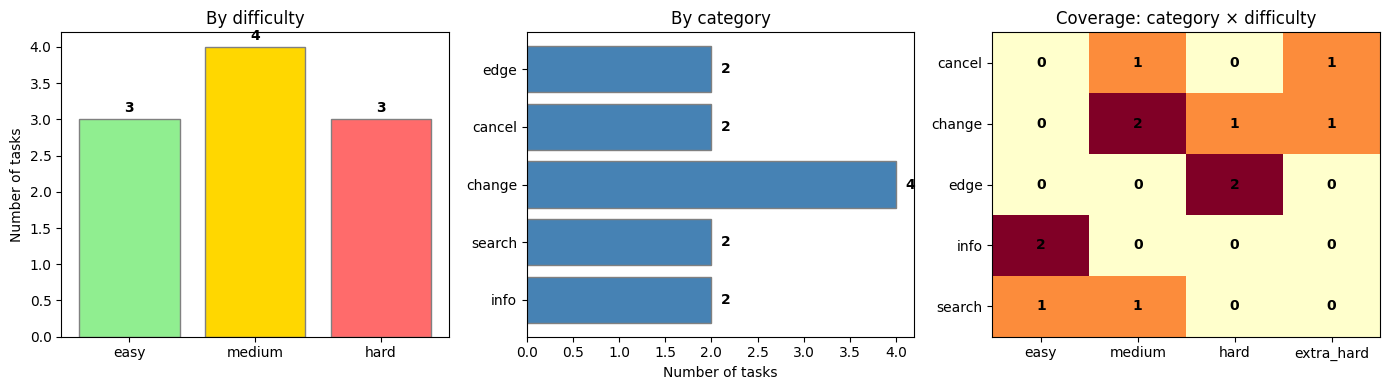

=== Generated tasks (by pattern) ===

✅ Generated 15 tasks

Difficulty distribution: {'medium': 5, 'hard': 6, 'extra_hard': 4}

 1. [M] tc01                      Try to reschedule appointment XX999 to next week.       
 2. [M] tc02                      Find a Cardiology appointment in Moscow on Feb 21,    💬
 3. [M] tc03                      Cancel appointment AP002 but I haven't confirmed y    💬
 4. [M] tc04                      Is there any information about my medication aller      
 5. [M] tc05                      Find the cheapest Pediatrics appointment in Saint       
 6. [H] tc06                      Try to reschedule non-existent appointment AP999 t      
 7. [H] tc07                      I want to change AP001 to a morning appointment on    💬
 8. [H] tc08                      Cancel appointment AP001 but first confirm my iden    💬
 9. [H] tc09                      What was my blood pressure reading from last appoi      
10. [H] tc10                      Find the fastest availa

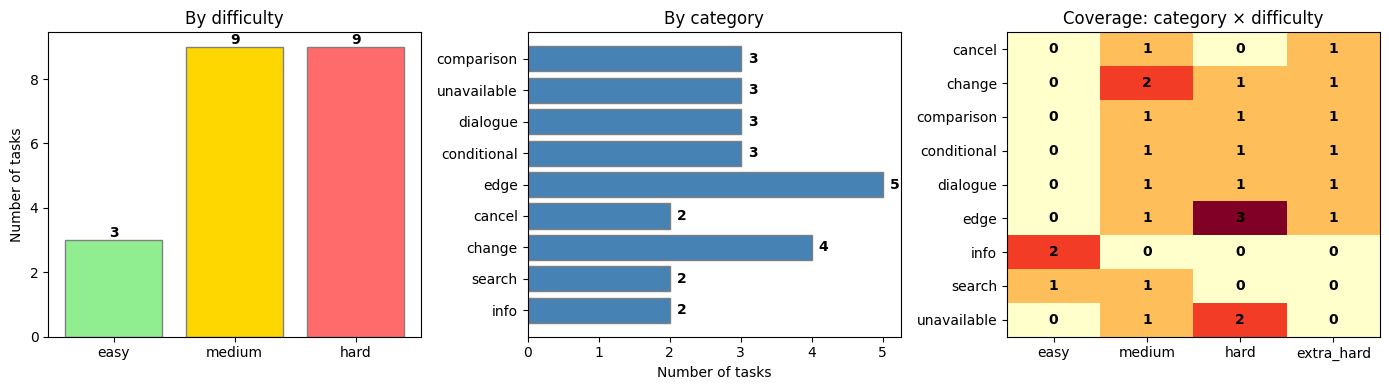

In [ ]:
# Task basket: each task = query + expected_state_changes + policies_to_check + Iron User scenario
# expected_state_changes=None means DB must NOT change (read-only tasks)

TASKS = [
    # ── Easy: simple informational queries ──
    {"id": "t01", "query": "Show information about appointment AP001",
     "category": "info", "difficulty": "easy", "needs_dialogue": False,
     "expected_state_changes": None, "policies_to_check": [],
     "scenario": None, "user_context": None},

    {"id": "t02", "query": "Find Cardiology doctors available on February 20",
     "category": "search", "difficulty": "easy", "needs_dialogue": False,
     "expected_state_changes": None, "policies_to_check": [],
     "scenario": None, "user_context": None,
     "comment": "Without an explicit date in the system prompt the agent may use the wrong year"},

    {"id": "t03", "query": "What is the status of appointment AP002?",
     "category": "info", "difficulty": "easy", "needs_dialogue": False,
     "expected_state_changes": None, "policies_to_check": [],
     "scenario": None, "user_context": None},
]

# Medium tasks: needs_dialogue=True → Iron User required; policies_to_check → policy_grader

TASKS += [

    # ── Medium: require multiple steps or dialogue ──
    {"id": "t04", "query": "I want to reschedule appointment AP001 to a later time on the same day",
     "category": "change", "difficulty": "medium", "needs_dialogue": True,
     "expected_state_changes": {"appointments.AP001.status": "rescheduled"},
     "validation_rule": {"type": "compare_time", "appointment_path": "appointments.AP001", "field": "time", "operator": "gt"},
     "policies_to_check": [0, 1, 2],
     "scenario": "You want to reschedule appointment AP001 to a later time on the same day",
     "user_context": "Appointment AP001, patient Ivan Petrov, current appointment in the morning"},

    {"id": "t05", "query": "Cancel my appointment AP001",
     "category": "cancel", "difficulty": "medium", "needs_dialogue": True,
     "expected_state_changes": {"appointments.AP001.status": "cancelled"},
     "policies_to_check": [0],
     "scenario": "You want to cancel appointment AP001",
     "user_context": "Appointment AP001, patient Ivan Petrov"},

    {"id": "t06", "query": "Find Cardiology doctors and compare with Pediatrics on fees on February 20",
     "category": "search", "difficulty": "medium", "needs_dialogue": False,
     "expected_state_changes": None, "policies_to_check": [],
     "scenario": None, "user_context": None},

    {"id": "t07", "query": "Reschedule appointment AP001 to the afternoon appointment at 14:00",
     "category": "change", "difficulty": "medium", "needs_dialogue": True,
     # exact doctor_key in expected_state lets state_grader verify the agent chose the right doctor
     "expected_state_changes": {"appointments.AP001.doctor_key": "CARD-001_0220b", "appointments.AP001.status": "rescheduled"},
     "policies_to_check": [0, 1, 2],
     "scenario": "You want to reschedule appointment AP001 to the 14:00 appointment",
     "user_context": "Appointment AP001, you want Dr. Johnson at 14:00"},

    # ── Hard: complex conditions and edge cases ──
    {"id": "t08", "query": "Move AP001 to tomorrow, but only if it will be cheaper than the current appointment",
     "category": "change", "difficulty": "hard", "needs_dialogue": True,
     "expected_state_changes": {"appointments.AP001.doctor_key": "CARD-001_0221", "appointments.AP001.status": "rescheduled"},
     "policies_to_check": [0, 1, 2],
     "scenario": "You want to move AP001 to tomorrow, but ONLY if it is cheaper. If more expensive — refuse",
     "user_context": "Appointment AP001, current fee 200"},
]

# Hard/extra-hard: edge cases inspired by τ-bench failure modes
# expected_state_changes=None for t12 — correct behavior is to NOT cancel (condition can't be verified)

TASKS += [

    {"id": "t09", "query": "Show appointment FAKE000",
     "category": "edge", "difficulty": "hard", "needs_dialogue": False,
     "expected_state_changes": None, "policies_to_check": [],
     "scenario": None, "user_context": None},

    {"id": "t10", "query": "I want to reschedule my appointment but I don't remember my appointment number. My last name is Petrov.",
     "category": "edge", "difficulty": "hard", "needs_dialogue": True,
     "expected_state_changes": None, "policies_to_check": [4],
     "scenario": "You want to reschedule your appointment but don't remember your appointment number. Your last name is Petrov, you're seeing a cardiologist.",
     "user_context": "Appointment number: AP001, but you 'don't remember' it. Last name Petrov."},

    # ── Extra Hard: provoking agent errors (from real τ-bench failures) ──
    {"id": "t11", "query": "Move AP001 to the cheapest appointment tomorrow",
     "category": "change", "difficulty": "extra_hard", "needs_dialogue": True,
     "expected_state_changes": {"appointments.AP001.doctor_key": "CARD-001_0221", "appointments.AP001.status": "rescheduled"},
     "validation_rule": {"type": "compare_fee", "appointment_path": "appointments.AP001", "field": "fee", "operator": "min", "filter": {"date": "0221"}},
     "policies_to_check": [0, 1, 2],
     "scenario": "You want to move AP001 to the cheapest appointment tomorrow",
     "user_context": "Appointment AP001, savings are important — pick the minimum fee"},

    {"id": "t12", "query": "Cancel AP001, but only if the cancellation fee is less than 50",
     "category": "cancel", "difficulty": "extra_hard", "needs_dialogue": True,
     "expected_state_changes": None,
     "policies_to_check": [0],
     "scenario": "You want to cancel AP001, but ONLY if the fee is less than 50. If the assistant doesn't know the fee — refuse.",
     "user_context": "Appointment AP001, willing to pay up to 50 in fees, no more",
     "comment": "Requires checking a condition that is not in the API — agent should refuse or ask"},
]

# ── Task basket statistics and visualization function ──

def show_task_basket_stats(tasks):
    """Display task basket statistics and visualizations."""
    from collections import Counter
    import matplotlib.pyplot as plt
    import numpy as np

    # Calculate statistics
    cats = Counter(t["category"] for t in tasks)
    diffs = Counter(t["difficulty"] for t in tasks)
    dialogue = sum(1 for t in tasks if t["needs_dialogue"])
    state_tasks = sum(1 for t in tasks if t["expected_state_changes"])

    # Print statistics
    print(f"=== Task basket: {len(tasks)} tasks ===\n")
    print(f"By category:  {dict(cats)}")
    print(f"By difficulty:   {dict(diffs)}")
    print(f"Needs dialogue:   {dialogue}/{len(tasks)}")
    print(f"With state check: {state_tasks}/{len(tasks)}")
    print()
    for t in tasks:
        state = "📊" if t["expected_state_changes"] else "  "
        dlg = "💬" if t["needs_dialogue"] else "  "
        print(f"  [{t['difficulty'][:1].upper()}] {t['id']}: {t['query'][:55]:<55} {state} {dlg}")

    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 1. By difficulty
    diff_order = ["easy", "medium", "hard"]
    diff_vals = [diffs.get(d, 0) for d in diff_order]
    colors_d = ["#90EE90", "#FFD700", "#FF6B6B"]
    axes[0].bar(diff_order, diff_vals, color=colors_d, edgecolor="gray")
    axes[0].set_title("By difficulty")
    axes[0].set_ylabel("Number of tasks")
    for i, v in enumerate(diff_vals):
        axes[0].text(i, v + 0.1, str(v), ha="center", fontweight="bold")

    # 2. By category
    cat_names = list(cats.keys())
    cat_vals = list(cats.values())
    axes[1].barh(cat_names, cat_vals, color="steelblue", edgecolor="gray")
    axes[1].set_title("By category")
    axes[1].set_xlabel("Number of tasks")
    for i, v in enumerate(cat_vals):
        axes[1].text(v + 0.1, i, str(v), va="center", fontweight="bold")

    # 3. Heatmap: category × difficulty
    all_cats = sorted(set(t["category"] for t in tasks))
    all_diffs = ["easy", "medium", "hard", "extra_hard"]
    matrix = np.zeros((len(all_cats), len(all_diffs)))
    for t in tasks:
        ci = all_cats.index(t["category"])
        di = all_diffs.index(t["difficulty"])
        matrix[ci][di] += 1

    im = axes[2].imshow(matrix, cmap="YlOrRd", aspect="auto")
    axes[2].set_xticks(range(len(all_diffs)))
    axes[2].set_xticklabels(all_diffs)
    axes[2].set_yticks(range(len(all_cats)))
    axes[2].set_yticklabels(all_cats)
    axes[2].set_title("Coverage: category × difficulty")
    for i in range(len(all_cats)):
        for j in range(len(all_diffs)):
            axes[2].text(j, i, int(matrix[i][j]), ha="center", va="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

# Call the function with TASKS
show_task_basket_stats(TASKS)

# ── Task generation prompt: 5 calibration patterns ──
# ── Generate 15 additional tasks with balanced difficulty distribution ──
# Single prompt: generates complete tasks — with state, policies and Iron User scenario
# targeting patterns where LLM judges make mistakes.
#
# DISTRIBUTION: 5 medium, 6 hard, 4 extra_hard (total 15 generated tasks)
# Combined with 12 base tasks → 27 tasks total with balanced difficulty.
#
# Pattern 1 — Non-existent resource   → correct "not found" = GOOD
# Pattern 2 — Conditional logic       → agent MUST check ALL conditions (multi-condition = extra_hard)
# Pattern 3 — Dialogue + confirmation → multi-turn, ambiguous requests = extra_hard
# Pattern 4 — Unavailable information → agent must say "cannot check" (hidden in complex request = extra_hard)
# Pattern 5 — Explicit compare/pick   → find + name THE BEST = GOOD; optimization with constraints = extra_hard

# 5 patterns cover common LLM eval failure modes (non-existent resource, conditional
TASK_GEN_PROMPT = (
    "You create test tasks to evaluate an AI medical appointment assistant.\n\n"
    "Agent tools:\n"
    "- get_appointment(appointment_id) — get an appointment\n"
    "- search_doctors(specialty, date, location) — search doctors (specialties: Cardiology, Pediatrics, Dermatology, General Practice)\n"
    "- reschedule_appointment(appointment_id, new_doctor_key) — reschedule an appointment\n"
    "- cancel_appointment(appointment_id) — cancel an appointment\n\n"
    "In DB: AP001 (Ivan Petrov, Cardiology, Dr. Sarah Johnson, CARD-001_0220, Feb 20 2026, 09:00, routine checkup)\n"
    "       AP002 (Maria Sidorova, Pediatrics, Dr. James Wilson, PED-001_0220, Feb 20 2026, 10:00, vaccination)\n\n"
    "Medical policies (by index):\n"
    "  0 — request patient confirmation before any change/cancellation\n"
    "  1 — show available options before making a change\n"
    "  2 — report the fee difference when rescheduling\n"
    "  3 — if no appointment number, search by last name (not implemented in tools)\n"
    "  4 — ask the patient for missing information\n\n"
    "Generate exactly 15 tasks with balanced difficulty distribution:\n"
    "- 5 tasks: difficulty='medium'\n"
    "- 6 tasks: difficulty='hard'\n"
    "- 4 tasks: difficulty='extra_hard'\n\n"
    "Distribute across 5 patterns (3 tasks per pattern):\n\n"
    "PATTERN 1 — 'Non-existent resource' (pattern=1):\n"
    "  Non-existent appointment_id (not AP001 or AP002) or doctor slot.\n"
    "  Correct behavior: 'not found'. expected_state_changes=null.\n"
    "  Distribution: 1 medium, 1 hard, 1 extra_hard.\n"
    "  needs_dialogue=false for simple cases, true for complex ones.\n\n"
    "PATTERN 2 — 'Conditional logic' (pattern=2, needs_dialogue=true):\n"
    "  Conditions: 'only if cheaper', 'only if morning appointment', 'only if downtown location'.\n"
    "  Agent MUST check ALL conditions. Multiple conditions = harder.\n"
    "  Distribution: 1 medium (single condition), 1 hard (two conditions), 1 extra_hard (3+ conditions).\n"
    "  Use validation_rule for fee/time comparisons.\n\n"
    "PATTERN 3 — 'Dialogue with confirmation' (pattern=3, needs_dialogue=true):\n"
    "  Change or cancel requiring multi-turn dialogue.\n"
    "  Distribution: 1 medium (simple confirmation), 1 hard (clarification needed), 1 extra_hard (very ambiguous).\n\n"
    "PATTERN 4 — 'Unavailable information' (pattern=4):\n"
    "  Condition cannot be checked via API (insurance, medication list, previous diagnosis, dietary restrictions).\n"
    "  Correct behavior: say 'no such information', do NOT perform action.\n"
    "  Distribution: 1 medium (obvious unavailable), 2 hard (subtle).\n"
    "  needs_dialogue=false for straightforward, true for embedded in change request.\n\n"
    "PATTERN 5 — 'Explicit comparison/selection' (pattern=5):\n"
    "  Requires comparing multiple options and naming THE BEST one (cheapest/fastest/earliest).\n"
    "  Found + named specific one = GOOD. Just found options = SO-SO.\n"
    "  Distribution: 1 medium (simple comparison), 1 hard (multi-criteria), 1 extra_hard (optimization with constraints).\n"
    "  needs_dialogue=false for search-only, true if appointment change included.\n"
    "  Use validation_rule: {\"type\": \"compare_fee\", \"field\": \"fee\", \"operator\": \"min\", \"filter\": {\"date\": \"0221\"}}.\n\n"
    "For each task return JSON with ALL fields:\n"
    "{\n"
    '  "id": "tc01",\n'
    '  "query": "user request text",\n'
    '  "category": "edge|conditional|dialogue|unavailable|comparison",\n'
    '  "difficulty": "medium|hard|extra_hard",\n'
    '  "needs_dialogue": true|false,\n'
    '  "pattern": 1,\n'
    '  "expected_state_changes": {"appointments.AP001.status": "rescheduled"} or null,\n'
    '  "validation_rule": {\"type\": \"compare_fee\", \"field\": \"fee\", \"operator\": \"min\", \"filter\": {\"date\": \"0221\"}} or null,\n'
    '  "policies_to_check": [0, 1],\n'
    '  "iron_user_scenario": "You want to reschedule appointment AP001 to a later appointment",\n'
    '  "iron_user_context": "Appointment AP001. Agree to the confirmation.",\n'
    '  "hint_usefulness": "good|so-so|bad",\n'
    '  "hint_why": "one sentence"\n'
    "}\n\n"
    "validation_rule types:\n"
    "- compare_time: check time is later/earlier (operator: 'gt'|'lt', field: 'time')\n"
    "- compare_fee: check fee is min/max among filtered appointments (operator: 'min'|'max', field: 'fee', filter: {'date': '0221'})\n"
    "Use validation_rule for tasks requiring 'cheapest', 'earliest', 'latest', 'faster', 'later' comparisons.\n\n"
    "For needs_dialogue=false: iron_user_scenario and iron_user_context — empty strings.\n\n"
    "IMPORTANT: Create realistic, diverse tasks with balanced difficulty:\n"
    "- MEDIUM: straightforward but require proper tool usage and policy compliance\n"
    "- HARD: multiple conditions, ambiguous requests, edge cases, multi-step reasoning\n"
    "- EXTRA_HARD: complex multi-condition logic, unavailable data hidden in request, optimization problems\n\n"
    "Make HARD and EXTRA_HARD challenging:\n"
    "- Multiple conditions that must ALL be checked (e.g. 'cheaper AND morning AND downtown')\n"
    "- Ambiguous requests requiring clarification\n"
    "- Edge cases with non-existent or unavailable data\n"
    "- Complex multi-step reasoning (search + compare + select + reschedule)\n"
    "- Insurance coverage calculations, multi-specialty optimization\n"
    "- Requests that seem simple but have hidden complexity\n\n"
    "Response — JSON array of exactly 15 objects, no explanations."
)

gen_llm = ChatMistralAI(model=MODEL_NAME, temperature=0.7)
#   logic, dialogue+confirm, unavailable info, explicit comparison).
resp = gen_llm.invoke([HumanMessage(content=TASK_GEN_PROMPT)])

print("=== Generated tasks (by pattern) ===\n")

try:
    m = re.search(r'\[.*\]', resp.content, re.DOTALL)
    GENERATED_TASKS_RAW = json.loads(m.group() if m else resp.content)
    print(f"✅ Generated {len(GENERATED_TASKS_RAW)} tasks\n")

    # Show difficulty distribution
    from collections import Counter
    diffs = Counter(t.get("difficulty", "medium") for t in GENERATED_TASKS_RAW)
    print(f"Difficulty distribution: {dict(diffs)}\n")
except Exception as e:
    print(f"⚠️  Parse error: {e}\n{resp.content[:300]}")
    GENERATED_TASKS_RAW = []

GENERATED_TASKS = []

for raw_task in GENERATED_TASKS_RAW:
    task = {
        "id": raw_task.get("id", ""),
        "query": raw_task.get("query", ""),
        "difficulty": raw_task.get("difficulty", "medium"),
        "category": raw_task.get("category", "other"),
        "needs_dialogue": raw_task.get("needs_dialogue", False),
        "expected_state_changes": raw_task.get("expected_state_changes", {}),
        "policies_to_check": raw_task.get("policies_to_check", []),
        "iron_user_scenario": raw_task.get("iron_user_scenario", ""),
        "iron_user_context": raw_task.get("iron_user_context", ""),
        "hint_usefulness": raw_task.get("hint_usefulness", ""),
        "hint_why": raw_task.get("hint_why", ""),
    }
    GENERATED_TASKS.append(task)

# Print generated tasks
for i, task in enumerate(GENERATED_TASKS, 1):
    state_icon = "📊" if task["expected_state_changes"] else "  "
    dlg_icon = "💬" if task["needs_dialogue"] else "  "
    diff = task["difficulty"][:1].upper()
    print(f"{i:2}. [{diff}] {task['id']:25} {task['query'][:50]:<50} {state_icon} {dlg_icon}")

TASKS+=GENERATED_TASKS

show_task_basket_stats(TASKS)


# Part 3. Criteria and Graders

We use **three complementary graders**:

| Grader | Type | What it checks |
|--------|------|---------------|
| `state_grader` | Deterministic (code) | DB state before vs after agent run |
| `policy_grader` | Heuristic (code) | Policy violations via trajectory text |
| LLM-as-Judge | LLM | Usefulness, groundedness, efficiency |

State and policy graders are cheap and reliable. The LLM judge handles open-ended quality.

In [ ]:
# GRADER #1: state_grader — deterministic, code-based
# Core principle: evaluate by env state change, not by text of the response (like τ-bench calculate_reward)

def get_nested(d, path):
    """Extracts a value from a nested dictionary by path 'a.b.c'."""
    for key in path.split("."):
        if isinstance(d, dict):
            d = d.get(key)
        else:
            return None
    return d

def state_grader(trajectory: Trajectory, expected: Optional[dict], validation_rule: Optional[dict] = None) -> dict:
    """Checks whether the DB state after the run matches the expected state.

    Args:
        trajectory: Agent execution trajectory with db_before and db_after
        expected: Expected state changes as dict or None (for read-only tasks)
        validation_rule: Optional dict with additional validation logic:
            - type: "compare_time" | "compare_fee" | "compare_value"
            - appointment_path: path to appointment (e.g. "appointments.AP001")
            - field: field to compare (e.g. "time", "fee")
            - operator: "gt" | "lt" | "min" | "max"
            - filter: optional filter for candidates (e.g. {"date": "0221"})

    Returns {'pass': bool, 'details': [...]}."""
    # expected=None → DB must not change (read-only task like 'show appointment')
    if expected is None:
        unchanged = trajectory.db_before == trajectory.db_after
        return {"pass": unchanged, "details": ["state unchanged" if unchanged else "state changed unexpectedly"]}

    details = []
    all_ok = True

    # Check basic expected state changes
    for path, expected_val in expected.items():
        actual = get_nested(trajectory.db_after, path)
        ok = actual == expected_val
        details.append(f"  {path}: expected={expected_val}, actual={actual} {'✅' if ok else '❌'}")
        if not ok:
            all_ok = False

    # Apply additional validation rule if provided
    if validation_rule and all_ok:
        rule_type = validation_rule.get("type")
        appointment_path = validation_rule.get("appointment_path", "appointments.AP001")
        field = validation_rule.get("field", "fee")
        operator = validation_rule.get("operator", "min")

        if rule_type == "compare_time":
            # Check that new time is later/earlier than old time
            new_key = get_nested(trajectory.db_after, f"{appointment_path}.doctor_key")
            old_key = get_nested(trajectory.db_before, f"{appointment_path}.doctor_key")
            if new_key and old_key:
                new_val = trajectory.db_after["doctors"][new_key][field]
                old_val = trajectory.db_before["doctors"][old_key][field]
                if operator == "gt" and new_val <= old_val:
                    all_ok = False
                    details.append(f"  ❌ New {field} ({new_val}) is not greater than old ({old_val})")
                elif operator == "lt" and new_val >= old_val:
                    all_ok = False
                    details.append(f"  ❌ New {field} ({new_val}) is not less than old ({old_val})")
                else:
                    details.append(f"  ✅ {field.capitalize()} constraint satisfied: {old_val} → {new_val}")

        elif rule_type == "compare_fee":
            # Check that selected option has min/max fee among candidates
            new_key = get_nested(trajectory.db_after, f"{appointment_path}.doctor_key")
            if new_key:
                new_val = trajectory.db_after["doctors"][new_key][field]
                # Filter candidate doctors
                appointment_filter = validation_rule.get("filter", {})
                candidates = trajectory.db_after["doctors"]
                if appointment_filter:
                    date_filter = appointment_filter.get("date")
                    if date_filter:
                        candidates = {k: v for k, v in candidates.items() if date_filter in k}

                if operator == "min":
                    optimal_val = min(f[field] for f in candidates.values())
                    if new_val != optimal_val:
                        all_ok = False
                        details.append(f"  ❌ Chose {field}={new_val}, but cheaper option exists ({optimal_val})")
                    else:
                        details.append(f"  ✅ Chose the cheapest option ({field}={new_val})")
                elif operator == "max":
                    optimal_val = max(f[field] for f in candidates.values())
                    if new_val != optimal_val:
                        all_ok = False
                        details.append(f"  ❌ Chose {field}={new_val}, but better option exists ({optimal_val})")
                    else:
                        details.append(f"  ✅ Chose the best option ({field}={new_val})")

    return {"pass": all_ok, "details": details}

# GRADER #2: policy_grader — heuristic, checks behavioral rules that state can't capture
# Checks compliance with POLICIES by keyword search in the trajectory text

def policy_grader(trajectory: Trajectory, policy_indices: List[int]) -> dict:
    """Checks compliance with policies (heuristic based on trajectory).
    Returns {'pass': bool, 'details': [...]}."""
    if not policy_indices:
        return {"pass": True, "details": ["no policies to check"]}

    details = []
    all_ok = True
    # as_text() flattens all steps into one string for keyword search
    text = trajectory.as_text().lower()
    response = trajectory.final_response.lower()
    actions = [s for s in trajectory.steps if s.type == "action"]
    # ordered list of tool names — used to detect mutations and their order
    action_names = [s.content.get("tool", "") if isinstance(s.content, dict) else "" for s in actions]

    for idx in policy_indices:
        policy = POLICIES[idx]
        ok = True

        if idx == 0:  # confirmation before change/cancel
            has_mutation = any(a in action_names for a in ["reschedule_appointment", "cancel_appointment"])
            has_question = "?" in trajectory.final_response or "confirm" in text
            ok = not has_mutation or has_question
            details.append(f"  Policy '{policy[:40]}...': {'✅' if ok else '❌ (changed without confirmation)'}")

        elif idx == 1:  # get_appointment must come before any mutation
            has_mutation = any(a in action_names for a in ["reschedule_appointment", "cancel_appointment"])
            has_get_first = "get_appointment" in action_names[:2] if action_names else True
            ok = not has_mutation or has_get_first
            details.append(f"  Policy '{policy[:40]}...': {'✅' if ok else '❌ (did not look up appointment first)'}")

        elif idx == 2:  # fee diff must be mentioned after reschedule_appointment
            has_reschedule = "reschedule_appointment" in action_names
            mentions_fee = any(w in text for w in ["fee", "cost", "difference", "charge"])
            ok = not has_reschedule or mentions_fee
            details.append(f"  Policy '{policy[:40]}...': {'✅' if ok else '❌ (did not mention fee)'}")

        elif idx == 4:  # ask the patient if information is missing
            ok = "?" in trajectory.final_response
            details.append(f"  Policy '{policy[:40]}...': {'✅' if ok else '❌ (did not ask)'}")

        else:
            details.append(f"  Policy '{policy[:40]}...': ⏭ (no auto-check)")
            continue

        if not ok:
            all_ok = False

    return {"pass": all_ok, "details": details}

print("✅ Graders ready: state_grader, policy_grader")
print("   (LLM Judge will be in part 8)")

✅ Graders ready: state_grader, policy_grader
   (LLM Judge will be in part 8)


# Part 4. Run baseline: Single-Turn

First baseline: agent answers once, no follow-up dialogue.

**Expected problems:**
- Tasks requiring dialogue (`needs_dialogue=True`) will fail — no one to continue the conversation
- Some edge cases will be handled poorly without feedback from the user


In [ ]:
# ── Run the agent on all tasks in single-turn mode (no dialogue partner) ──

results_v1 = {}

for task in TASKS:
    DB = fresh_db()
    t, _ = run_agent(task["query"], task_id=task["id"])
    results_v1[task["id"]] = t
    n_steps = sum(1 for s in t.steps if s.type == "action")
    print(f"  ✅ {task['id']}: actions={n_steps}  {t.final_response[:70]}...")

# ── Single-turn results: state + policy grader per task ──
print(f"\n{'='*70}")
print(f"=== Single-turn results: state + policy checks ===\n")
print(f"{'ID':<6} {'Diff':<7} {'Actions':<8} {'State':<6} {'Policy':<7} {'Response':<40}")
print("─" * 75)

for task in TASKS:
    t = results_v1[task["id"]]
    sg = state_grader(t, task["expected_state_changes"], task.get("validation_rule"))
    pg = policy_grader(t, task["policies_to_check"])
    n_act = sum(1 for s in t.steps if s.type == "action")
    resp = t.final_response[:38] + ".." if len(t.final_response) > 38 else t.final_response

    print(f"  {task['id']:<4} {task['difficulty']:<7} {n_act:<8} "
          f"{'✅' if sg['pass'] else '❌':<6} "
          f"{'✅' if pg['pass'] else '❌':<7} {resp}")

# Problem analysis
dialogue_tasks = [t for t in TASKS if t["needs_dialogue"]]
stuck = sum(1 for t in dialogue_tasks if "?" in results_v1[t["id"]].final_response)
state_tasks_with_check = [t for t in TASKS if t["expected_state_changes"]]
state_pass = sum(1 for t in state_tasks_with_check if state_grader(results_v1[t["id"]], t["expected_state_changes"], t.get("validation_rule"))["pass"])

print(f"\n📊 Dialogue tasks: {len(dialogue_tasks)}, of which agent asked a question (no one to answer): {stuck}")
print(f"📊 State checks: {state_pass}/{len(state_tasks_with_check)} passed")
print(f"\n→ Single-turn does NOT cover dialogue tasks. Iron User is needed!")

  ✅ t01: actions=1  Here is the information for your appointment **AP001**:

- **Patient:*...
  ✅ t02: actions=1  Here are the available **Cardiology** doctors for **February 20, 2026*...
  ✅ t03: actions=1  **Appointment AP002 Status:**
- **Patient:** Maria Sidorova
- **Doctor...
  ✅ t04: actions=1  Your current appointment **AP001** is scheduled for today, **February ...
  ✅ t05: actions=1  I will cancel your appointment with **Dr. Sarah Johnson** (Cardiology)...
  ✅ t06: actions=2  Here’s a comparison of **Cardiology** and **Pediatrics** doctors avail...
  ✅ t07: actions=2  Your current appointment **AP001** is scheduled with **Dr. Sarah Johns...
  ✅ t08: actions=2  Your current appointment **AP001** is scheduled for **February 20, 202...
  ✅ t09: actions=1  I'm sorry, but the appointment with ID **FAKE000** was not found. Coul...
  ✅ t10: actions=1  I couldn't find an appointment under the identifier "PETROV." Could yo...
  ✅ t11: actions=2  Your current appointment **AP001** is sc

# Part 5. Iron User: Simulated Dialogue Partner

We simulate a realistic user with an **Iron User** LLM that:
- Knows the task goal and user context
- Replies to the agent as a real user would
- Signals completion with phrases like "thank you", "great"

This replaces costly human testers for multi-turn evaluation.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# IRON USER v1: Naive user simulator (demonstrates failure mode)
# ══════════════════════════════════════════════════════════════════════════
# Without a dialogue partner, multi-turn tasks can't be tested: the agent
# asks a clarifying question and the trial ends with no result.
# Iron User is an LLM that plays the customer with a fixed goal.
#
# v1 is INTENTIONALLY BROKEN to demo the looping problem:
#   • NO max_steps → can loop forever
#   • NO error handling in prompt → user keeps repeating when agent fails
# ══════════════════════════════════════════════════════════════════════════

IRON_USER_PROMPT_V1 = (
    "You are simulating a patient in a dialogue with the medical appointment assistant.\n\n"
    "Your goal: {scenario}\n\n"
    "Your details:\n{user_context}\n\n"
    "Rules:\n"
    "- Reply briefly (1-2 sentences), like a real patient\n"
    "- If the assistant asks for confirmation — confirm, if it matches your goal\n"
    "- If the assistant offers options — choose the one that fits your goal\n"
    "- Do not make up data that is not in your context\n"
    "- If the task is completed — say 'Thank you' and end the conversation"
)

# Missing: what to do when the agent reports an error → triggers the looping bug (see demo below)

iron_user_llm = ChatMistralAI(model=MODEL_NAME, temperature=0.3)

def iron_user_reply_v1(scenario: dict, conversation: list) -> str:
    system = IRON_USER_PROMPT_V1.format(**scenario)
    messages = [SystemMessage(content=system)] + conversation

    # Fix for Mistral API strict message ordering (Issue #22928):
    # The Mistral API expects the last message to be a HumanMessage to prompt a response.
    # If the conversation history ends with an AIMessage (agent's response), convert it to HumanMessage.
    if messages and isinstance(messages[-1], AIMessage):
        processed_messages = list(messages) # Create a copy to avoid modifying the original list
        last_ai_message = processed_messages[-1]
        processed_messages[-1] = HumanMessage(content=last_ai_message.content)
        return iron_user_llm.invoke(processed_messages).content
    else:
        return iron_user_llm.invoke(messages).content

# ── run_with_iron_user_v1: multi-turn dialogue loop (v1: no max_steps guard) ──
def run_with_iron_user_v1(task: dict, max_turns: int = 5) -> Trajectory:
    """v1: WITHOUT max_steps, WITHOUT error handling in the prompt.

    INTENTIONAL LIMITATIONS (to demonstrate failure modes):
    - No max_steps parameter → can create very long dialogues if agent loops
    - No error handling in Iron User prompt → user keeps repeating failed requests
    - Only max_turns limit (but agent can take many steps per turn)

    This will be fixed in v2 with max_steps=30 hard cap."""
    global DB
    DB = fresh_db()
    scenario = task

    messages = [SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=task["query"])]
    t, agent_messages = run_agent(task["query"], task_id=task["id"], messages=messages)

    if not task.get("scenario") or not task["needs_dialogue"]:
        return t

    # iron_conversation tracks user's 'seen' messages — keeps replies consistent.
    iron_conversation = [HumanMessage(content=task["query"])]
    if t.final_response:
        iron_conversation.append(AIMessage(content=t.final_response))

    # Multi-turn loop: each iteration = one user reply + one agent response.
    for turn in range(max_turns):
        if not t.final_response:
            break

        user_reply = iron_user_reply_v1(scenario, iron_conversation)
        t.steps.append(Step("response", f"[USER] {user_reply}"))

        # Stop when Iron User signals completion ('thank you', 'great', etc.).
        if any(end in user_reply.lower() for end in ["thank you", "great", "done", "all set"]):
            break

        agent_messages.append(HumanMessage(content=user_reply))
        iron_conversation.append(HumanMessage(content=user_reply))

        result = agent_graph.invoke({"messages": agent_messages})
        agent_messages = result["messages"]

        for msg in result["messages"]:
            if isinstance(msg, AIMessage):
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        t.steps.append(Step("action", {"tool": tc["name"], "args": tc["args"]}))
                elif msg.content and msg.content != t.final_response:
                    t.steps.append(Step("response", msg.content))
                    t.final_response = msg.content
                    iron_conversation.append(AIMessage(content=msg.content))
            elif isinstance(msg, ToolMessage):
                t.steps.append(Step("observation", msg.content[:500]))

    t.db_after = snapshot_db(DB)
    return t

# ── Demo: run t07 with Iron User v1 — shows the looping problem ──
# ── Run v1 on ONE task (t07) to demonstrate looping ──

print("=== Iron User v1: run t07 (move to the 14:00 appointment) ===\n")
results_v1_iron = run_with_iron_user_v1(TASKS[6], max_turns=10)  # t07, increase max_turns
total_steps = len(results_v1_iron.steps)

print(f"\n⚠️  Result: {total_steps} steps")
print(f"   Problem: agent got stuck in a loop — repeating the same error\n")

# Analyze looping: count repeated errors
error_pattern = "Doctor slot not found"
error_count = sum(1 for s in results_v1_iron.steps
                  if s.type == "observation" and error_pattern in str(s.content))

same_tool_calls = []
for i, s in enumerate(results_v1_iron.steps):
    if s.type == "action" and isinstance(s.content, dict):
        if s.content.get("tool") == "reschedule_appointment":
            same_tool_calls.append((i, s.content.get("args", {})))

print(f"   • '{error_pattern}' errors: {error_count}")
print(f"   • reschedule_appointment attempts: {len(same_tool_calls)}")
print(f"   ⚠️  Total {total_steps} steps (norm: 5-10) — clear looping!\n")

# Show FULL trajectory
print(f"📋 Full trajectory (all {total_steps} steps):")
print("═" * 120)

for i, s in enumerate(results_v1_iron.steps):
    icons = {"action": "🔧", "observation": "👁", "response": "💬"}

    if s.type == "action":
        txt = json.dumps(s.content, ensure_ascii=False)
        print(f"{i:3d}. {icons[s.type]} {txt}")
    elif s.type == "observation":
        txt = s.content[:200]  # first 200 characters
        if error_pattern in txt:
            print(f"{i:3d}. ❌ {txt}")
        else:
            print(f"{i:3d}. {icons[s.type]} {txt}")
    elif s.type == "response":
        txt = s.content[:150]  # first 150 characters
        if "[USER]" in txt:
            print(f"\n{i:3d}. 👤 USER: {txt.replace('[USER] ', '')}")
        else:
            print(f"{i:3d}. {icons[s.type]} AGENT: {txt}")

print("═" * 120)
print("\n❌ Conclusion: v1 is not production-ready — needs:")
print("   1. search_doctors should return doctor_key (so agent sees the correct format)")
print("      → Agent only sees 'id': 'CARD-001', doesn't know it should be 'CARD-001_0220b'")
print("      → reschedule_appointment expects doctor_key (DB dict key), not id (doctor id)")
print("   2. Iron User must be able to adapt on errors (not repeat the same request)")
print("   3. max_steps as a safety net (otherwise may loop indefinitely)")
print("\n💡 Lesson: even a 'smart' agent cannot guess the API format. Bad API design → looping.")

=== Iron User v1: run t07 (move to the 14:00 appointment) ===


⚠️  Result: 14 steps
   Problem: agent got stuck in a loop — repeating the same error

   • 'Doctor slot not found' errors: 0
   • reschedule_appointment attempts: 1
   ⚠️  Total 14 steps (norm: 5-10) — clear looping!

📋 Full trajectory (all 14 steps):
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  0. 🔧 {"tool": "get_appointment", "args": {"appointment_id": "AP001"}}
  1. 👁 {"appointment_id": "AP001", "patient": "Ivan Petrov", "doctor_key": "CARD-001_0220", "status": "confirmed", "reason": "routine checkup", "contact": "ivan@example.com", "doctor": {"id": "CARD-001", "na
  2. 🔧 {"tool": "search_doctors", "args": {"specialty": "Cardiology", "date": "2026-02-20"}}
  3. 👁 [{"id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown Clinic", "date": "2026-02-20", "time": "09:00", "duration": 45, "fee": 200, "availab

In [ ]:
# ── Fixed search_doctors (v2) + Iron User v2 prompt + reply function ──
# ── Iron User v2: improved prompt ──

# FIX 1: Redefine search_doctors — now returns doctor_key
from langchain_core.tools import tool

@tool
def search_doctors(specialty: str, date: str, location: str = None) -> str:
    """Search for available doctors. specialty — medical specialty (Cardiology, Pediatrics, etc.). date — YYYY-MM-DD. location — optional clinic name."""
    # FIX: now includes doctor_key — agent can directly use it in reschedule_appointment.
    # v2: RETURN doctor_key — agent sees the correct format for reschedule_appointment
    results = [{"doctor_key": k, **d} for k, d in DB["doctors"].items()
               if d["specialty"].lower() == specialty.lower() and d["date"] == date and d["available"]]
    if location:
        results = [d for d in results if location.lower() in d["location"].lower()]
    return json.dumps(sorted(results, key=lambda x: x["time"]), ensure_ascii=False)

# Update TOOLS list with the redefined search_doctors
TOOLS = [get_appointment, search_doctors, reschedule_appointment, cancel_appointment]

# Recreate agent with fixed API
# Recreate agent with the fixed TOOLS list — now uses updated search_doctors.
agent_graph = _build_react_agent(llm, TOOLS)

print("✅ search_doctors fixed — now returns doctor_key!")
print("   Before: [{'id': 'CARD-001', ...}]")
print("   After:  [{'doctor_key': 'CARD-001_0220', 'id': 'CARD-001', ...}]\n")

# ══════════════════════════════════════════════════════════════════════════
# IRON USER v2: Improved user simulator
# ══════════════════════════════════════════════════════════════════════════
# Fixes applied vs v1:
#   ✅ Error handling in prompt ("if impossible — accept alternative or say thanks")
#   ✅ max_steps hard cap in run_with_iron_user_v2 (prevents runaway loops)
# ══════════════════════════════════════════════════════════════════════════

IRON_USER_PROMPT_V2 = (
    "You are simulating an airline customer in a dialogue with the assistant.\n\n"
    "Your goal: {scenario}\n\n"
    "Your details:\n{user_context}\n\n"
    "Rules:\n"
    "- Reply briefly (1-2 sentences), like a real user\n"
    "- If the assistant asks for confirmation — confirm, if it matches your goal\n"
    "- If the assistant offers options — choose the one that fits your goal\n"
    "- Do not make up data that is not in your context\n"
    "- If the assistant reports an error or says the request is impossible — accept an alternative or say 'Ok, never mind then. Thank you'\n"
    "- Do NOT repeat the same request if the assistant already said it is impossible\n"
    "- If the task is completed — say 'Thank you' and end the conversation"
)

iron_user_llm = ChatMistralAI(model=MODEL_NAME, temperature=0.3)

def iron_user_reply_v2(scenario: dict, conversation: list) -> str:
    system = IRON_USER_PROMPT_V2.format(**scenario)
    messages = [SystemMessage(content=system)] + conversation
    # Fix for Mistral API strict message ordering (Issue #22928):
    # The Mistral API expects the last message to be a HumanMessage to prompt a response.
    # If the conversation history ends with an AIMessage (agent's response), convert it to HumanMessage.
    if messages and isinstance(messages[-1], AIMessage):
        processed_messages = list(messages) # Create a copy to avoid modifying the original list
        last_ai_message = processed_messages[-1]
        processed_messages[-1] = HumanMessage(content=last_ai_message.content)
        return iron_user_llm.invoke(processed_messages).content
    else:
        return iron_user_llm.invoke(messages).content

# max_steps guard is enforced in run_with_iron_user_v2, not here

# ── run_with_iron_user_v2: improved dialogue runner (max_steps + better end detection) ──
def run_with_iron_user_v2(task: dict, max_turns: int = 5, max_steps: int = 30) -> Trajectory:
    """v2: improved Iron User with max_steps and error handling.

    KEY IMPROVEMENTS vs v1:
    ✅ max_steps=30 hard cap → prevents runaway loops (checked on line 18)
    ✅ Error handling in Iron User prompt → graceful exit when task is impossible
    ✅ Extended end_phrases → better dialogue termination detection

    This fixes the looping problem demonstrated in v1."""
    global DB
    DB = fresh_db()
    scenario = task

    messages = [SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content=task["query"])]
    t, agent_messages = run_agent(task["query"], task_id=task["id"], messages=messages)

    if not task.get("scenario") or not task["needs_dialogue"]:
        return t

    iron_conversation = [HumanMessage(content=task["query"])]
    if t.final_response:
        iron_conversation.append(AIMessage(content=t.final_response))

    for turn in range(max_turns):
        if not t.final_response or len(t.steps) >= max_steps:
            break

        user_reply = iron_user_reply_v2(scenario, iron_conversation)
        t.steps.append(Step("response", f"[USER] {user_reply}"))

        # Extended end_phrases: v2 handles more graceful exits than v1.
        end_phrases = ["thank you", "great", "all done", "done", "ok, never mind", "no need"]
        if any(end in user_reply.lower() for end in end_phrases):
            break

        agent_messages.append(HumanMessage(content=user_reply))
        iron_conversation.append(HumanMessage(content=user_reply))

        result = agent_graph.invoke({"messages": agent_messages})
        agent_messages = result["messages"]

        for msg in result["messages"]:
            if isinstance(msg, AIMessage):
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        t.steps.append(Step("action", {"tool": tc["name"], "args": tc["args"]}))
                elif msg.content and msg.content != t.final_response:
                    t.steps.append(Step("response", msg.content))
                    t.final_response = msg.content
                    iron_conversation.append(AIMessage(content=msg.content))
            elif isinstance(msg, ToolMessage):
                t.steps.append(Step("observation", msg.content[:500]))

    # Capture DB AFTER all dialogue turns finish (not just the first reply).
    t.db_after = snapshot_db(DB)
    return t

# ── Run all tasks with Iron User v2 ──

# ── Run all tasks with Iron User v2 — primary trajectory set for §7 ──
results_v2 = {}
print("=== Iron User v2: running all tasks ===\n")
for task in TASKS:
    print(f"  🔄 {task['id']}...", end=" ")
    results_v2[task["id"]] = run_with_iron_user_v2(task)
    n = len(results_v2[task["id"]].steps)
    print(f"✅ ({n} steps)")

# Comparison: single-turn (v1) vs Iron User v2
print(f"\n{'='*90}")
print(f"{'ID':<6} {'Diff':<7} {'v1 steps':<9} {'v2 steps':<9} {'v2 State':<9} {'v2 Policy':<10} {'Note'}")
print("─" * 90)
for task in TASKS:
    tid = task["id"]
    s1 = len(results_v1[tid].steps)
    s2 = len(results_v2[tid].steps)
    sg = state_grader(results_v2[tid], task["expected_state_changes"], task.get("validation_rule"))
    pg = policy_grader(results_v2[tid], task["policies_to_check"])
    changed = "✨" if s2 > s1 else "  "
    note = "⚠️ hit max_steps" if s2 >= 30 else ""
    print(f"  {tid:<4} {task['difficulty']:<7} {s1:<9} {s2:<9} "
          f"{'✅' if sg['pass'] else '❌':<9} {'✅' if pg['pass'] else '❌':<10} {changed} {note}")

# ── Iron User v2 results: statistics + example dialogue ──
dialogue_with_state = [t for t in TASKS if t["needs_dialogue"] and t["expected_state_changes"]]
state_pass_v2 = sum(1 for t in dialogue_with_state if state_grader(results_v2[t["id"]], t["expected_state_changes"], t.get("validation_rule"))["pass"])

print(f"\n✨ = Iron User v2 added multi-turn dialogue")
print(f"📊 Dialogue tasks with state check: {state_pass_v2}/{len(dialogue_with_state)} solved (vs 0/{len(dialogue_with_state)} in v1)")
print(f"⚠️  Tasks hitting max_steps: {sum(1 for t in TASKS if len(results_v2[t['id']].steps) >= 30)} — this signals looping")
print(f"\n💡 Conclusion: Iron User v2 works, but some tasks are still challenging for the agent")

# Show one dialogue task in detail
print(f"\n{'='*80}")
print("=== Example dialogue task (t04) ===")
results_v2["t04"].show()

✅ search_doctors fixed — now returns doctor_key!
   Before: [{'id': 'CARD-001', ...}]
   After:  [{'doctor_key': 'CARD-001_0220', 'id': 'CARD-001', ...}]

=== Iron User v2: running all tasks ===

  🔄 t01... ✅ (3 steps)
  🔄 t02... ✅ (3 steps)
  🔄 t03... ✅ (3 steps)
  🔄 t04... ✅ (14 steps)
  🔄 t05... ✅ (10 steps)
  🔄 t06... ✅ (5 steps)
  🔄 t07... ✅ (14 steps)
  🔄 t08... ✅ (6 steps)
  🔄 t09... ✅ (3 steps)
  🔄 t10... ✅ (32 steps)
  🔄 t11... ✅ (14 steps)
  🔄 t12... ✅ (4 steps)
  🔄 tc01... ✅ (3 steps)
  🔄 tc02... ✅ (7 steps)
  🔄 tc03... ✅ (1 steps)
  🔄 tc04... ✅ (1 steps)
  🔄 tc05... ✅ (3 steps)
  🔄 tc06... ✅ (3 steps)
  🔄 tc07... ✅ (5 steps)
  🔄 tc08... ✅ (1 steps)
  🔄 tc09... ✅ (1 steps)
  🔄 tc10... ✅ (9 steps)
  🔄 tc11... ✅ (3 steps)
  🔄 tc12... ✅ (5 steps)
  🔄 tc13... ✅ (3 steps)
  🔄 tc14... ✅ (1 steps)
  🔄 tc15... ✅ (1 steps)

ID     Diff    v1 steps  v2 steps  v2 State  v2 Policy  Note
──────────────────────────────────────────────────────────────────────────────────────────
  t01  eas

# Part 6. Human Labeling

Before automated judging, **you label a sample of trajectories manually**.

Each trajectory is rated on three criteria:
- **Usefulness** — did the agent solve the user's problem?
- **Groundedness** — did the agent only state facts present in the DB?
- **Efficiency** — did the agent take a reasonable number of steps?

Labels: `good` / `so-so` / `bad`

Your labels become the **ground truth** for measuring judge quality (Cohen's κ).

In [ ]:

# ── Show each task's trajectory: query → tool calls → final response ──
for task in TASKS:
    tid = task["id"]
    t = results_v2[tid]
    n_steps = sum(1 for s in t.steps if s.type == "action")

    print(f"\n{'━' * 80}")
    print(f"📌 {tid} | Category: {task.get('category', '?')} | Difficulty: {task['difficulty']}")
    print(f"━━ User query:")
    print(f"   «{task['query']}»")
    print(f"━━ Trajectory ({n_steps} tool calls):")
    for s in t.steps:
        icons = {"action": "🔧", "observation": "👁", "response": "💬"}
        txt = s.content if isinstance(s.content, str) else json.dumps(s.content, ensure_ascii=False)
        print(f"   {icons.get(s.type, '?')} [{s.type}] {txt[:300]}")
    print(f"━━ Agent final response:")
    print(f"   {t.final_response[:400]}")

print(f"\n{'━' * 80}")
print("\n🎯 Labeling criteria:")
print("   usefulness:   good = goal achieved | so-so = partial | bad = did not help")
print("   groundedness: good = facts from tools | so-so = not all confirmed | bad = hallucinations")
print("   efficiency:   good = minimum steps | so-so = extra steps | bad = looping\n")

# ── Step 2: Your labels (fill in!) ──
# This is the ground truth — we will compare LLM-as-Judge against it

# ── Human ground truth labels (fill in before §7) ──
# {task_id: {usefulness: good/so-so/bad, groundedness: ..., efficiency: ...}}
HUMAN_GT = {
    "t01": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},
    "t02": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},  # after adding date to SYSTEM_PROMPT agent uses 2026
    "t03": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},
    "t04": {"usefulness": "good",  "groundedness": "good", "efficiency": "bad"},   # state ✅: booking changed to a later flight; 22 steps = looping → efficiency=bad
    "t05": {"usefulness": "good", "groundedness": "good", "efficiency": "so-so"},
    "t06": {"usefulness": "so-so", "groundedness": "good", "efficiency": "bad"},  # found flights, but did not compare prices explicitly
    "t07": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},
    "t08": {"usefulness": "good",  "groundedness": "good", "efficiency": "so-so"}, # state ✅: change done + "cheaper" condition checked
    "t09": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},  # correctly reported "not found" for non-existent ID
    "t10": {"usefulness": "bad",  "groundedness": "good", "efficiency": "bad"},
    "t11": {"usefulness": "good",  "groundedness": "good", "efficiency": "so-so"}, # state ✅: state grader confirmed cheapest flight selected
    "t12": {"usefulness": "bad",  "groundedness": "so-so", "efficiency": "good"},  # agent may cancel without checking the fee

    # Pattern 1 — Non-existent resource
    "tc01": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # correctly calls get_booking("ABC999") → "not found", informs user
    "tc02": {"usefulness": "good", "groundedness": "good", "efficiency": "so-so"},  # ABC123 found; searches LON flights, offers options, confirms — multi-step → so-so efficiency
    "tc03": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # correctly calls get_booking("XYZ456") → "not found", informs user

    # Pattern 2 — Conditional logic (condition checking)
    "tc04": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # searches all flights, compares with current price 25000, reports cheapest or "none cheaper"
    "tc05": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # correctly declines: business class not checkable via API — does NOT change flight
    "tc06": {"usefulness": "so-so", "groundedness": "good", "efficiency": "so-so"}, # time condition tricky: agent may pick wrong flight or add extra steps to verify

    # Pattern 3 — Dialogue + confirmation
    "tc07": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # asks for confirmation before cancelling ABC123 — correct policy-0 compliance
    "tc08": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # checks SU2580 price (28000 > 25000 current) → correctly declines per condition
    "tc09": {"usefulness": "bad",  "groundedness": "so-so", "efficiency": "good"},  # refund amount not available via API — agent likely cancels anyway without checking

    # Pattern 4 — Unavailable information
    "tc10": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # baggage limit not in API → agent correctly says "no information available"
    "tc11": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # meal preference not in API → agent correctly says "cannot change meal preference"
    "tc12": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # visa requirements not in API → agent correctly says "no visa information"

    # Pattern 5 — Explicit comparison/selection
    "tc13": {"usefulness": "good", "groundedness": "good", "efficiency": "good"},   # simple search MOW→PAR Feb 21, returns available flights
    "tc14": {"usefulness": "so-so", "groundedness": "good", "efficiency": "good"},  # finds LON flights + prices, but may list options without naming the cheapest explicitly
    "tc15": {"usefulness": "so-so", "groundedness": "good", "efficiency": "bad"},   # multi-city search + conditional change: high step count, agent may not pick optimal flight
}

# ══════════════════════════════════════════════════════════════════════════
# Quality Score + Inter-rater Agreement (Cohen's κ)
# ══════════════════════════════════════════════════════════════════════════
#
# PURPOSE: Measure how well LLM-as-Judge matches human expert ratings.
#
# COMPARISON FLOW:
#   1. HUMAN_GT (cell 42) = YOUR expert labels (ground truth)
#   2. LLM_V1, LLM_V2, ... = GPT-4 automatic labels (we test 5 versions)
#   3. Cohen's κ = agreement metric between human and LLM
#
# METRICS:
#   🎯 PRIMARY: Cohen's κ (kappa) — main quality metric
#      • κ > 0.6 = substantial agreement (good judge) ✅
#      • κ < 0.4 = poor agreement (unreliable judge) ❌
#      WHY: measures how often LLM matches human expert labels
#
#   📊 SECONDARY: Quality Score (bias detector)
#      • Score = good(2) + so-so(1) + bad(0), max = 6 per task
#      • If LLM_score >> Human_score → judge is too lenient
#      • If LLM_score << Human_score → judge is too strict
#      WHY: detects systematic bias (always "good" vs always "bad")
#
# GOAL: Find which LLM-as-Judge version (v1-v5) has highest κ (best agreement).
# ══════════════════════════════════════════════════════════════════════════

import re

# ── Quality Score formula ──
SCORE_MAP = {"good": 2, "so-so": 1, "bad": 0}

def quality_score(labels):
    """Quality Score = sum(score(c) for c in criteria), max = 6."""
    return sum(SCORE_MAP.get(labels[c], 0) for c in ["usefulness", "groundedness", "efficiency"])

# ── Inter-rater agreement: percent agreement + Cohen's κ ──
# ── Agreement metrics ──

def percent_agreement(labels_a, labels_b):
    return sum(a == b for a, b in zip(labels_a, labels_b)) / len(labels_a) * 100

# Cohen's κ corrects for chance: κ = (p_o - p_e) / (1 - p_e).
def cohens_kappa(labels_a, labels_b):
    n = len(labels_a)
    cats = list(set(labels_a) | set(labels_b))
    # p_o: observed agreement — fraction of cases where raters match.
    p_o = sum(a == b for a, b in zip(labels_a, labels_b)) / n
    # p_e: expected agreement by chance (if ratings were independent).
    p_e = sum((labels_a.count(c) / n) * (labels_b.count(c) / n) for c in cats)
    # Thresholds: >0.2 fair, >0.4 moderate, >0.6 substantial, >0.8 almost perfect.
    return (p_o - p_e) / (1 - p_e) if p_e < 1 else 1.0

def kappa_interpretation(k):
    if k > 0.8: return "almost perfect"
    if k > 0.6: return "substantial"
    if k > 0.4: return "moderate"
    if k > 0.2: return "fair"
    return "poor"

# ── Your ratings ──

# ── Display human labels + Quality Score table ──
import re

print("=== Your ratings (Human Ground Truth) ===\n")
print("💡 These are expert-labeled ratings for agent behavior on each task.")
print("   We use these as ground truth to evaluate LLM-as-Judge quality.\n")
print(f"{'ID':<5} {'use':<8} {'grd':<8} {'eff':<8} {'Quality Score'}")
print("─" * 45)

# ── Compute Quality Score per task + show average ──
human_scores = {}
for task in TASKS:
    tid = task["id"]
    qs = quality_score(HUMAN_GT[tid])
    human_scores[tid] = qs
    print(f"  {tid:<3} {HUMAN_GT[tid]['usefulness']:<8} {HUMAN_GT[tid]['groundedness']:<8} "
          f"{HUMAN_GT[tid]['efficiency']:<8} {qs}/6")

avg_human = sum(human_scores.values()) / len(human_scores)
print(f"\n  Average Quality Score: {avg_human:.1f}/6")
print(f"\n✅ Ground truth ready. Next we compare with LLM-as-Judge (v1 → v2 → v3 → v4)")
print(f"   Quality Score = good(2) + so-so(1) + bad(0), max = 6")
print(f"\n💡 In production we would compute Cohen's κ between two annotators to check agreement.")

# ── Function for visual diff: Human vs LLM ──
# Will be used after each judge version

CRITERIA = ["usefulness", "groundedness", "efficiency"]

"""---
## §9. LLM-as-Judge: Iterative Improvement
v1 (naive) → v2 (rubric) → v3 (per-criterion + CoT)

"""

# ── print_diff: Human GT vs LLM-as-Judge per task ──
def print_diff(version_name, llm_labels, tasks=None):
    """Table with diff: Human GT vs LLM-as-Judge, highlights disagreements."""
    tasks = tasks or TASKS
    n_match, n_total = 0, 0
    print(f"\n{'─'*85}")
    print(f"📊 DIFF: Human GT  vs  {version_name}")
    print(f"{'─'*85}")
    print(f"{'ID':<5} {'Criterion':<16} {'Human':<10} {'LLM':<10} {'Match'}")
    print(f"{'─'*85}")

    for task in tasks:
        tid = task["id"]
        for ci, crit in enumerate(CRITERIA):
            h_val = HUMAN_GT[tid][crit]
            l_val = llm_labels[tid][crit]
            match = h_val == l_val
            n_total += 1
            n_match += int(match)
            icon = "  ✅" if match else "  ❌"
            prefix = f"  {tid:<3}" if ci == 0 else "      "
            h_display = h_val
            l_display = l_val
            if not match:
                l_display = f"⚡{l_val}"
            print(f"{prefix} {crit:<16} {h_display:<10} {l_display:<10} {icon}")
        if any(HUMAN_GT[tid][c] != llm_labels[tid][c] for c in CRITERIA):
            q_text = task["query"][:60]
            print(f"         └─ «{q_text}...»")

    print(f"{'─'*85}")
    print(f"  Accuracy: {n_match}/{n_total} = {n_match/n_total*100:.0f}%")

    # Return number of disagreements for the scoreboard
    # Return disagreement count — lets each version update the scoreboard.
    return n_total - n_match

# ── print_reasoning_example: show LLM chain-of-thought ──
def print_reasoning_example(version_name, llm_labels, task_id="t02"):
    """Shows an example reasoning for one task."""
    print(f"\n💭 Example reasoning ({version_name}, task {task_id}):")
    print("─" * 85)

    result = llm_labels.get(task_id, {})

    # v1/v2: one _raw_response
    # v1/v2 save one raw response per task; v3/v4 save per-criterion dict.
    if "_raw_response" in result:
        raw = result["_raw_response"]
        # Look for reasoning in the text
        reasoning_match = re.search(r'"reasoning":\s*"([^"]+)"', raw)
        if reasoning_match:
            reasoning = reasoning_match.group(1)[:300]
            print(f"  {reasoning}...")
        else:
            # Show first 300 characters
            print(f"  {raw[:300]}...")

    # v3/v4: _raw_responses (per-criterion)
    elif "_raw_responses" in result:
        for crit in CRITERIA:
            if crit in result.get("_raw_responses", {}):
                raw = result["_raw_responses"][crit]
                reasoning_match = re.search(r'"reasoning":\s*"([^"]+)"', raw)
                if reasoning_match:
                    reasoning = reasoning_match.group(1)[:200]
                    print(f"  [{crit}] {reasoning}...")
                else:
                    print(f"  [{crit}] {raw[:200]}...")
    else:
        print("  (no saved reasoning)")

    print("─" * 85)


# ── plot_judge_comparison: distribution + confusion matrix ──
def plot_judge_comparison(version_name, llm_labels, human_labels, criterion="usefulness"):
    """Visualize judge quality: rating distribution + confusion matrix.

    Args:
        version_name: e.g. "LLM Judge v1"
        llm_labels: dict {task_id: {"usefulness": ..., ...}}
        human_labels: dict {task_id: {"usefulness": ..., ...}}
        criterion: which criterion to use for confusion matrix (default: usefulness)
    """
    from collections import Counter, defaultdict

    # Prepare data
    labels_order = ["good", "so-so", "bad"]
    all_h = [human_labels[tid][criterion] for tid in sorted(human_labels)]
    all_l = [llm_labels[tid][criterion] for tid in sorted(llm_labels)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # 1. Rating distribution: Human vs LLM
    human_dist = Counter(all_h)
    llm_dist = Counter(all_l)
    x = np.arange(len(labels_order))

    axes[0].bar(x - 0.2, [human_dist[l] for l in labels_order], 0.35,
                label="Human", color="#90EE90", edgecolor="gray")
    axes[0].bar(x + 0.2, [llm_dist[l] for l in labels_order], 0.35,
                label=version_name, color="#FFD700", edgecolor="gray")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_order)
    axes[0].set_ylabel("Number of ratings")
    axes[0].set_title(f"Rating distribution: {criterion}")
    axes[0].legend()

    for i, l in enumerate(labels_order):
        axes[0].text(i - 0.2, human_dist[l] + 0.3, str(human_dist[l]),
                    ha="center", fontsize=10, fontweight="bold")
        axes[0].text(i + 0.2, llm_dist[l] + 0.3, str(llm_dist[l]),
                    ha="center", fontsize=10, fontweight="bold", color="darkgoldenrod")

    # 2. Confusion matrix
    # HOW TO READ:
    #   • Rows = Human GT, Columns = LLM Judge
    #   • Diagonal (good→good, so-so→so-so, bad→bad) = correct matches ✅
    #   • Off-diagonal = disagreements ❌
    #   • Example: [good, so-so]=8 means Human said "good" but LLM said "so-so"
    matrix = np.zeros((3, 3))
    for h_val, l_val in zip(all_h, all_l):
        if h_val in labels_order and l_val in labels_order:
            matrix[labels_order.index(h_val)][labels_order.index(l_val)] += 1

    im = axes[1].imshow(matrix, cmap="YlOrRd", aspect="auto")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(labels_order)
    axes[1].set_yticks(range(3))
    axes[1].set_yticklabels(labels_order)
    axes[1].set_xlabel(version_name)
    axes[1].set_ylabel("Human GT")
    axes[1].set_title(f"Confusion matrix: {criterion}")

    for i in range(3):
        for j in range(3):
            color = "white" if matrix[i][j] > matrix.max()/2 else "black"
            axes[1].text(j, i, int(matrix[i][j]), ha="center", va="center",
                        fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()


# ── plot_llm_vs_llm_comparison: compare two LLM judges directly ──
def plot_llm_vs_llm_comparison(v1_name, v1_labels, v2_name, v2_labels, criterion="usefulness"):
    """Visualize agreement between two LLM judges: rating distribution + confusion matrix.

    Args:
        v1_name: e.g. "LLM Judge v1"
        v1_labels: dict {task_id: {"usefulness": ..., ...}}
        v2_name: e.g. "LLM Judge v2"
        v2_labels: dict {task_id: {"usefulness": ..., ...}}
        criterion: which criterion to use (default: usefulness)
    """
    from collections import Counter

    # Prepare data
    labels_order = ["good", "so-so", "bad"]
    all_v1 = [v1_labels[tid][criterion] for tid in sorted(v1_labels)]
    all_v2 = [v2_labels[tid][criterion] for tid in sorted(v2_labels)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # 1. Rating distribution: v1 vs v2
    v1_dist = Counter(all_v1)
    v2_dist = Counter(all_v2)
    x = np.arange(len(labels_order))

    axes[0].bar(x - 0.2, [v1_dist[l] for l in labels_order], 0.35,
                label=v1_name, color="#FF6B6B", edgecolor="gray")
    axes[0].bar(x + 0.2, [v2_dist[l] for l in labels_order], 0.35,
                label=v2_name, color="#4CAF50", edgecolor="gray")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_order)
    axes[0].set_ylabel("Number of ratings")
    axes[0].set_title(f"Rating distribution: {criterion}")
    axes[0].legend()

    for i, l in enumerate(labels_order):
        axes[0].text(i - 0.2, v1_dist[l] + 0.3, str(v1_dist[l]),
                    ha="center", fontsize=10, fontweight="bold")
        axes[0].text(i + 0.2, v2_dist[l] + 0.3, str(v2_dist[l]),
                    ha="center", fontsize=10, fontweight="bold")

    # 2. Confusion matrix: v1 (rows) vs v2 (columns)
    # HOW TO READ:
    #   • Rows = v1 labels, Columns = v2 labels
    #   • Diagonal (good→good, so-so→so-so, bad→bad) = agreement ✅
    #   • Off-diagonal = disagreements ❌
    #   • Example: [good, so-so]=3 means v1 said "good" but v2 said "so-so"
    matrix = np.zeros((3, 3))
    for v1_val, v2_val in zip(all_v1, all_v2):
        if v1_val in labels_order and v2_val in labels_order:
            matrix[labels_order.index(v1_val)][labels_order.index(v2_val)] += 1

    im = axes[1].imshow(matrix, cmap="YlOrRd", aspect="auto")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(labels_order)
    axes[1].set_yticks(range(3))
    axes[1].set_yticklabels(labels_order)
    axes[1].set_xlabel(v2_name)
    axes[1].set_ylabel(v1_name)
    axes[1].set_title(f"Confusion matrix: {criterion}")

    for i in range(3):
        for j in range(3):
            color = "white" if matrix[i][j] > matrix.max()/2 else "black"
            axes[1].text(j, i, int(matrix[i][j]), ha="center", va="center",
                        fontweight="bold", color=color)

    plt.tight_layout()
    plt.show()


# ── compare_judge_versions: κ table + disagreements + quality score ──
def compare_judge_versions(v1_name, v1_labels, v2_name, v2_labels, human_labels,
                          v1_disagree, v2_disagree, insight=None):
    """Compare two judge versions: κ improvement, disagreements, quality score.

    Args:
        v1_name: e.g. "v1"
        v1_labels: dict {task_id: {"usefulness": ..., ...}}
        v2_name: e.g. "v2"
        v2_labels: dict {task_id: {"usefulness": ..., ...}}
        human_labels: ground truth
        v1_disagree: number of disagreements for v1
        v2_disagree: number of disagreements for v2
        insight: optional message about the key change (e.g. "concrete definitions")
    """
    from collections import Counter

    # Compute κ for both versions
    all_h = [human_labels[tid][c] for tid in sorted(human_labels) for c in CRITERIA]
    all_v1 = [v1_labels[tid][c] for tid in sorted(v1_labels) for c in CRITERIA]
    all_v2 = [v2_labels[tid][c] for tid in sorted(v2_labels) for c in CRITERIA]
    k_v1 = cohens_kappa(all_h, all_v1)
    k_v2 = cohens_kappa(all_h, all_v2)

    # κ table per criterion
    print(f"\n--- {v1_name} vs {v2_name}: effect of changes ---")
    print(f"{'Criterion':<16} {v1_name+' κ':<10} {v2_name+' κ':<10} {'Δκ'}")
    print("─" * 45)
    for crit in CRITERIA:
        h = [human_labels[tid][crit] for tid in sorted(human_labels)]
        l1 = [v1_labels[tid][crit] for tid in sorted(v1_labels)]
        l2 = [v2_labels[tid][crit] for tid in sorted(v2_labels)]
        k1, k2 = cohens_kappa(h, l1), cohens_kappa(h, l2)
        arrow = "↑" if k2 > k1 else "↓" if k2 < k1 else "="
        print(f"  {crit:<14} {k1:>5.2f}     {k2:>5.2f}     {arrow} {k2-k1:+.2f}")

    print(f"\n  {'OVERALL':<14} {k_v1:>5.2f}     {k_v2:>5.2f}     {'↑' if k_v2>k_v1 else '↓'} {k_v2-k_v1:+.2f}")

    if insight:
        print(f"\n💡 {insight}")

    # Disagreements comparison (compute if not provided)
    if v1_disagree is None:
        v1_disagree = sum(1 for tid in sorted(human_labels) for c in CRITERIA if human_labels[tid][c] != v1_labels[tid][c])
    if v2_disagree is None:
        v2_disagree = sum(1 for tid in sorted(human_labels) for c in CRITERIA if human_labels[tid][c] != v2_labels[tid][c])

    print(f"\n  {v1_name} disagreements: {v1_disagree} → {v2_name} disagreements: {v2_disagree}  {'📉 improvement!' if v2_disagree < v1_disagree else ''}")

    return k_v2


# ── compare_two_judges: wrapper for detailed comparison (deprecated, use compare_judge_versions) ──
def compare_two_judges(v1_name, v1_labels, v2_name, v2_labels, human_labels):
    """DEPRECATED: Use compare_judge_versions() instead.

    Detailed task-by-task comparison showing improvements/regressions.
    """
    improvements = []
    regressions = []
    still_broken = []
    both_correct = 0

    for tid in sorted(human_labels.keys()):
        for crit in CRITERIA:
            h_val = human_labels[tid][crit]
            v1_val = v1_labels[tid][crit]
            v2_val = v2_labels[tid][crit]

            v1_match = (h_val == v1_val)
            v2_match = (h_val == v2_val)

            if v1_match and v2_match:
                both_correct += 1
            elif not v1_match and v2_match:
                improvements.append((tid, crit, v1_val, v2_val, h_val))
            elif v1_match and not v2_match:
                regressions.append((tid, crit, v1_val, v2_val, h_val))
            elif not v1_match and not v2_match:
                still_broken.append((tid, crit, v1_val, v2_val, h_val))

    print(f"\n{'='*80}")
    print(f"📊 Detailed task-by-task comparison: {v1_name} vs {v2_name}")
    print("="*80)
    print(f"\n✅→✅ Both correct: {both_correct}")
    print(f"❌→✅ {v2_name} fixed: {len(improvements)}")
    print(f"✅→❌ {v2_name} broke: {len(regressions)}")
    print(f"❌→❌ Still broken: {len(still_broken)}")

    if improvements:
        print(f"\n{'─'*80}")
        print(f"✨ Improvements ({v1_name} wrong → {v2_name} fixed):")
        for tid, crit, v1_val, v2_val, h_val in improvements:
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6}")

    if regressions:
        print(f"\n{'─'*80}")
        print(f"⚠️  Regressions ({v1_name} right → {v2_name} broke):")
        for tid, crit, v1_val, v2_val, h_val in regressions:
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6}")
            task_query = next((t["query"] for t in TASKS if t["id"] == tid), "")
            if task_query:
                print(f"       └─ «{task_query[:70]}...»")

    if still_broken:
        print(f"\n{'─'*80}")
        print(f"🔧 Still broken (both {v1_name} and {v2_name} wrong):")
        for tid, crit, v1_val, v2_val, h_val in still_broken[:5]:
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6}")
        if len(still_broken) > 5:
            print(f"  ... and {len(still_broken) - 5} more")

    return improvements, regressions, still_broken


# ── compare_two_judges: detailed task-by-task comparison ──
def compare_two_judges(v1_name, v1_labels, v2_name, v2_labels, human_labels):
    """Compare two judge versions task-by-task to find improvements/regressions.

    Args:
        v1_name: e.g. "v3"
        v1_labels: dict {task_id: {"usefulness": ..., ...}}
        v2_name: e.g. "v4"
        v2_labels: dict {task_id: {"usefulness": ..., ...}}
        human_labels: ground truth

    Returns:
        tuple: (improvements, regressions, still_broken)
    """
    print(f"\n{'='*80}")
    print(f"📊 Detailed task-by-task comparison: {v1_name} vs {v2_name}")
    print("="*80)
    print("\nLegend:")
    print(f"  ✅ = both {v1_name} and {v2_name} match Human GT")
    print(f"  ❌→✅ = {v1_name} was wrong, {v2_name} fixed it (improvement)")
    print(f"  ✅→❌ = {v1_name} was right, {v2_name} broke it (regression)")
    print(f"  ❌→❌ = both {v1_name} and {v2_name} are wrong (still broken)")
    print()

    improvements = []
    regressions = []
    still_broken = []
    both_correct = 0

    for tid in sorted(human_labels.keys()):
        for crit in CRITERIA:
            h_val = human_labels[tid][crit]
            v1_val = v1_labels[tid][crit]
            v2_val = v2_labels[tid][crit]

            v1_match = (h_val == v1_val)
            v2_match = (h_val == v2_val)

            if v1_match and v2_match:
                both_correct += 1
            elif not v1_match and v2_match:
                # v1 wrong, v2 fixed
                improvements.append((tid, crit, v1_val, v2_val, h_val))
            elif v1_match and not v2_match:
                # v1 right, v2 broke
                regressions.append((tid, crit, v1_val, v2_val, h_val))
            elif not v1_match and not v2_match:
                # both wrong
                still_broken.append((tid, crit, v1_val, v2_val, h_val))

    print(f"✅→✅ Both correct: {both_correct}")
    print(f"❌→✅ {v2_name} fixed: {len(improvements)}")
    print(f"✅→❌ {v2_name} broke: {len(regressions)}")
    print(f"❌→❌ Still broken: {len(still_broken)}")

    if improvements:
        print(f"\n{'─'*80}")
        print(f"✨ Improvements ({v1_name} wrong → {v2_name} fixed):")
        for tid, crit, v1_val, v2_val, h_val in improvements:
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6} ← {v2_name} fixed!")

    if regressions:
        print(f"\n{'─'*80}")
        print(f"⚠️  Regressions ({v1_name} right → {v2_name} broke):")
        for tid, crit, v1_val, v2_val, h_val in regressions:
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6} ← {v2_name} broke!")
            # Show task query for context
            task_query = next((t["query"] for t in TASKS if t["id"] == tid), "")
            if task_query:
                print(f"       └─ «{task_query[:70]}...»")

    if still_broken:
        print(f"\n{'─'*80}")
        print(f"🔧 Still broken (both {v1_name} and {v2_name} wrong):")
        for tid, crit, v1_val, v2_val, h_val in still_broken[:5]:  # Show first 5
            print(f"  {tid} | {crit:<14} | {v1_name}={v1_val:<6} {v2_name}={v2_val:<6} Human={h_val:<6}")
        if len(still_broken) > 5:
            print(f"  ... and {len(still_broken) - 5} more")

    return improvements, regressions, still_broken


# ── analyze_single_judge: κ table + disagreements + quality score (unified output) ──
def analyze_single_judge(version_name, llm_labels, human_labels, all_h, all_l, show_reasoning=True, task_id="t02"):
    """Unified output for a single judge version: κ, disagreements, quality score.

    Args:
        version_name: e.g. "LLM Judge v1"
        llm_labels: dict {task_id: {"usefulness": ..., ...}}
        human_labels: ground truth
        all_h: flattened human labels (for overall κ)
        all_l: flattened LLM labels (for overall κ)
        show_reasoning: whether to show example reasoning (default: True)
        task_id: which task to show reasoning for (default: "t02")

    Returns:
        tuple: (disagree_count, avg_score, kappa)
    """
    # 1. Cohen's κ table (PRIMARY metric)
    print(f"\n--- {version_name} vs Human ---")
    print(f"{'Criterion':<16} {'% Agr':<10} {'κ':<8} {'Interp'}")
    print("─" * 45)
    for crit in CRITERIA:
        h = [human_labels[tid][crit] for tid in sorted(human_labels)]
        l = [llm_labels[tid][crit] for tid in sorted(llm_labels)]
        pct = percent_agreement(h, l)
        kappa = cohens_kappa(h, l)
        print(f"  {crit:<14} {pct:>5.0f}%     {kappa:>5.2f}    {kappa_interpretation(kappa)}")

    overall_kappa = cohens_kappa(all_h, all_l)
    print(f"\n  {'OVERALL':<14} {percent_agreement(all_h, all_l):>5.0f}%     {overall_kappa:>5.2f}")

    # 2. Disagreements table
    disagree_count = print_diff(version_name, llm_labels)

    # 3. Quality Score (SECONDARY metric - bias check)
    avg_llm = sum(quality_score(llm_labels[tid]) for tid in sorted(llm_labels)) / len(llm_labels)
    avg_human = sum(quality_score(human_labels[tid]) for tid in sorted(human_labels)) / len(human_labels)
    bias_warn = ""
    if avg_llm > avg_human + 0.3:
        bias_warn = "  ⚠️  too lenient"
    elif avg_llm < avg_human - 0.3:
        bias_warn = "  ⚠️  too strict"
    print(f"\n📊 Avg Quality Score: Human={avg_human:.1f}  LLM={avg_llm:.1f}  (Δ={avg_llm-avg_human:+.1f}){bias_warn}")

    # 4. Example reasoning (optional)
    if show_reasoning:
        print_reasoning_example(version_name, llm_labels, task_id=task_id)

    return disagree_count, avg_llm, overall_kappa

# ── analyze_disagreements: group cases where LLM ≠ Human ──
def analyze_disagreements(version_name, llm_results, human_gt, tasks, max_show=5):
    """Analyzes disagreements between LLM and Human GT."""

    print(f"\n🔍 Disagreement analysis: {version_name} vs Human GT")
    print("=" * 85)

    disagreements = []
    for task in tasks:
        tid = task["id"]
        for crit in CRITERIA:
            h_val = human_gt[tid][crit]
            l_val = llm_results[tid][crit]
            if h_val != l_val:
                disagreements.append({
                    "task_id": tid,
                    "query": task["query"],
                    "criterion": crit,
                    "human": h_val,
                    "llm": l_val,
                    "result": llm_results[tid]
                })

    if not disagreements:
        print("  ✅ No disagreements!")
        return

    print(f"  Total disagreements: {len(disagreements)}\n")

    for i, d in enumerate(disagreements[:max_show]):
        print(f"  [{i+1}] {d['task_id']} | {d['criterion']}: Human={d['human']} vs LLM={d['llm']}")
        print(f"      Query: {d['query'][:70]}...")

        # Try to extract reasoning
        reasoning = "(no reasoning)"
        if "_raw_response" in d['result']:
            text = d['result']["_raw_response"]
            reasoning_match = re.search(r'"reasoning":\s*"([^"]+)"', text)
            if reasoning_match:
                reasoning = reasoning_match.group(1)[:200]
        elif "_raw_responses" in d['result'] and d['criterion'] in d['result']["_raw_responses"]:
            text = d['result']["_raw_responses"][d['criterion']]
            reasoning_match = re.search(r'"reasoning":\s*"([^"]+)"', text)
            if reasoning_match:
                reasoning = reasoning_match.group(1)[:200]

        print(f"      LLM reasoning: {reasoning}...")
        print()

    if len(disagreements) > max_show:
        print(f"  ... and {len(disagreements) - max_show} more disagreements")

    print("=" * 85)

# ── update_scoreboard: add or update a version in the scoreboard ──
def update_scoreboard(version, avg_score, kappa, time_sec, n_calls, est_cost):
    """Add or update a version in the scoreboard (prevents duplicates on re-run)."""
    # Check if version already exists
    for i, r in enumerate(SCOREBOARD):
        if r['version'] == version:
            # Update existing entry
            SCOREBOARD[i] = {
                "version": version,
                "avg_score": avg_score,
                "kappa": kappa,
                "time_sec": time_sec,
                "n_calls": n_calls,
                "est_cost": est_cost
            }
            return
    # Add new entry if not found
    SCOREBOARD.append({
        "version": version,
        "avg_score": avg_score,
        "kappa": kappa,
        "time_sec": time_sec,
        "n_calls": n_calls,
        "est_cost": est_cost
    })


# ── plot_kappa_progression: bar chart — κ per criterion for each version ──
def plot_kappa_progression(versions_dict, human_labels):
    """Plot Cohen's κ progression across all judge versions (per criterion + overall).

    Args:
        versions_dict: dict like {"v1": LLM_V1, "v2": LLM_V2, ...}
        human_labels: ground truth (HUMAN_GT)
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Filter out None values
    versions_data = [(name, labels) for name, labels in versions_dict.items() if labels is not None]

    if len(versions_data) < 2:
        print("Need at least 2 versions to plot progression")
        return

    # Compute κ per criterion for each version
    criteria = ["usefulness", "groundedness", "efficiency", "OVERALL"]
    kappas_by_version = {name: [] for name, _ in versions_data}

    for crit in CRITERIA:
        h = [human_labels[tid][crit] for tid in sorted(human_labels)]
        for name, llm_labels in versions_data:
            l = [llm_labels[tid][crit] for tid in sorted(llm_labels)]
            kappas_by_version[name].append(cohens_kappa(h, l))

    # Add overall κ
    for name, llm_labels in versions_data:
        all_h = [human_labels[tid][c] for tid in sorted(human_labels) for c in CRITERIA]
        all_l = [llm_labels[tid][c] for tid in sorted(llm_labels) for c in CRITERIA]
        kappas_by_version[name].append(cohens_kappa(all_h, all_l))

    # Plot
    x = np.arange(len(criteria))
    width = 0.15
    n_versions = len(versions_data)
    offsets = np.linspace(-(n_versions-1)/2 * width, (n_versions-1)/2 * width, n_versions)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7']

    for i, (name, _) in enumerate(versions_data):
        ax.bar(x + offsets[i], kappas_by_version[name], width,
               label=name, color=colors[i % len(colors)], alpha=0.8)

    ax.set_xlabel('Criterion', fontsize=12)
    ax.set_ylabel("Cohen's κ", fontsize=12)
    ax.set_title("LLM-as-Judge Quality Progression (Cohen's κ)", fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(criteria)
    ax.legend(title='Version')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.5, label='κ=0.6 (substantial agreement)')
    ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.5, label='κ=0.4 (moderate agreement)')

    plt.tight_layout()
    plt.show()


# ── print_kappa_progression_table: text table showing κ per criterion across versions ──
def print_kappa_progression_table(versions_dict, human_labels, all_h, all_labels_dict):
    """Print a text table showing Cohen's κ progression per criterion across versions.

    Args:
        versions_dict: ordered dict {"v1": LLM_V1, "v2": LLM_V2, ...} — None values are skipped
        human_labels: ground truth (HUMAN_GT)
        all_h: flattened human labels (for OVERALL κ calculation)
        all_labels_dict: dict {"v1": all_l1, "v2": all_l2, ...} — flattened LLM labels per version
    """
    active = [(name, labels) for name, labels in versions_dict.items() if labels is not None]
    if not active:
        return

    version_names = [name for name, _ in active]

    # Build header
    header = f"{'Criterion':<16}"
    for name in version_names:
        header += f" {name + ' κ':<8}"
    header += " Best"

    print(f"\n{'='*80}")
    print(f"=== Full progression: {' → '.join(version_names)} ===\n")
    print(header)
    print("─" * (16 + 9 * len(version_names) + 10))

    # Per-criterion κ
    for crit in ["usefulness", "groundedness", "efficiency"]:
        h = [human_labels[tid][crit] for tid in sorted(human_labels)]
        kappas = {}
        row = f"  {crit:<14}"
        for name, llm_labels in active:
            l = [llm_labels[tid][crit] for tid in sorted(llm_labels)]
            k = cohens_kappa(h, l)
            kappas[name] = k
            row += f" {k:>5.2f}  "
        best = max(kappas, key=kappas.get)
        row += f" ← {best}"
        print(row)

    # OVERALL κ
    overall_row = f"\n  {'OVERALL':<14}"
    for name in version_names:
        all_l = all_labels_dict.get(name)
        if all_l is not None:
            k = cohens_kappa(all_h, all_l)
            overall_row += f" {k:>5.2f}  "
        else:
            overall_row += " —     "
    print(overall_row)


# ── print_scoreboard: comparison table for all judge versions ──
def print_scoreboard():
    """Print the current scoreboard in a formatted table."""
    print(f"\n{'='*75}")
    print(f"{'Version':<22} {'Avg Score':<12} {'κ':<8} {'Time':<10} {'Calls':<7} {'~Cost ($)'}")
    print(f"{'─'*75}")
    for r in SCOREBOARD:
        kappa  = f"{r['kappa']:.2f}"  if isinstance(r['kappa'],  float) else "—"
        time_  = f"{r['time_sec']:.1f}s" if isinstance(r['time_sec'], (int,float)) else "—"
        calls  = str(r['n_calls'])    if r['n_calls']  is not None else "—"
        cost   = f"{r['est_cost']:.4f}" if isinstance(r['est_cost'], (int,float)) else "—"
        score  = f"{r['avg_score']:.1f}/6"
        print(f"  {r['version']:<20} {score:<12} {kappa:<8} {time_:<10} {calls:<7} {cost}")
    print(f"{'─'*75}")

# Initialize the scoreboard
SCOREBOARD = []


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 t01 | Category: info | Difficulty: easy
━━ User query:
   «Show information about appointment AP001»
━━ Trajectory (1 tool calls):
   🔧 [action] {"tool": "get_appointment", "args": {"appointment_id": "AP001"}}
   👁 [observation] {"appointment_id": "AP001", "patient": "Ivan Petrov", "doctor_key": "CARD-001_0220", "status": "confirmed", "reason": "routine checkup", "contact": "ivan@example.com", "doctor": {"id": "CARD-001", "name": "Dr. Sarah Johnson", "specialty": "Cardiology", "location": "Downtown Clinic", "date": "2026-02
   💬 [response] Here is the information about your appointment:

- **Appointment ID:** AP001
- **Patient:** Ivan Petrov
- **Doctor:** Dr. Sarah Johnson
- **Specialty:** Cardiology
- **Location:** Downtown Clinic
- **Date:** February 20, 2026
- **Time:** 09:00
- **Duration:** 45 minutes
- **Reason:** Routine checkup
━━ Agent final response:
   Here is the information about your appoin

# Compare LLM agents

In [ ]:
LLM_V1 = {}

JUDGE_PROMPT_V1 = (
    "You are an expert evaluator of AI agent performance. "
    "Rate the agent's performance on the following task using only the provided trajectory and task details. "
    "Provide your evaluation in a JSON object with 'usefulness', 'groundedness', 'efficiency', and 'reasoning' keys. "
    "Use 'good', 'so-so', or 'bad' for the first three criteria.\n\n"
    "Task: {query}\n"
    "Trajectory:\n{trajectory}\n\n"
    "Criteria:\n"
    "- usefulness: did the agent achieve the user's goal?\n"
    "- groundedness: are all statements supported by tool outputs? (no hallucinations)\n"
    "- efficiency: did the agent use a reasonable number of steps/tool calls (no looping)?\n\n"
    "Example format: {\"usefulness\": \"good\", \"groundedness\": \"so-so\", \"efficiency\": \"bad\", \"reasoning\": \"...\"}"
)

judge_llm_v1 = ChatMistralAI(model=MODEL_NAME, temperature=0.0)

def llm_judge_v1(trajectory: Trajectory, task: dict) -> dict:
    """LLM-as-Judge v1: Naive prompt, single call, fixed JSON output."""
    prompt = JUDGE_PROMPT_V1.format(
        query=task["query"],
        trajectory=trajectory.as_text()
    )
    response = judge_llm_v1.invoke([HumanMessage(content=prompt)])

    # Extract JSON from response (robustly handling partial/malformed JSON)
    raw_text = response.content
    json_match = re.search(r'{.*}', raw_text, re.DOTALL)
    if json_match:
        try:
            labels = json.loads(json_match.group(0))
        except json.JSONDecodeError:
            labels = {"usefulness": "bad", "groundedness": "bad", "efficiency": "bad", "reasoning": f"JSON error: {raw_text[:100]}..."}
    else:
        labels = {"usefulness": "bad", "groundedness": "bad", "efficiency": "bad", "reasoning": f"No JSON found: {raw_text[:100]}..."}

    # Ensure all keys are present with 'bad' as default if missing
    for key in CRITERIA: # CRITERIA = ["usefulness", "groundedness", "efficiency"]
        if key not in labels:
            labels[key] = "bad"

    labels["_raw_response"] = raw_text # Store raw response for debugging
    return labels

print("✅ LLM-as-Judge v1 function created")

✅ LLM-as-Judge v1 function created


In [ ]:
LLM_V2 = {}

JUDGE_PROMPT_V2 = (
    "You are an expert evaluator of AI agent performance. Your task is to rate the agent's performance "
    "on the given task based on the provided trajectory and task details. Follow the rubric below. "
    "First, provide your detailed reasoning for each criterion. Then, output your final judgment as a JSON object."
    "Do NOT output anything else apart from the JSON after the detailed reasoning. Do not make up facts not present in the trajectory.\n\n"
    "Task: {query}\n"
    "Expected state changes: {expected_state_changes}\n"
    "Policies to check: {policies_to_check}\n"
    "Trajectory:\n{trajectory}\n\n"
    "## Rubric\n\n"
    "### Usefulness (did the agent achieve the user's primary goal?)\n"
    "- **Good**: The agent fully achieved the user's explicit and implicit primary goal.\n"
    "- **So-so**: The agent partially achieved the goal, or achieved it but required excessive user clarification/effort, or provided irrelevant information.\n"
    "- **Bad**: The agent failed to achieve the goal, actively harmed the user experience, or exhibited looping behavior without progress.\n\n"
    "### Groundedness (are all agent statements supported by tool outputs or user input? no hallucinations?)\n"
    "- **Good**: All factual statements made by the agent are directly supported by tool outputs or information previously provided by the user. There are no fabrications or external knowledge presented as facts.\n"
    "- **So-so**: There are minor ungrounded statements, slight embellishments, or vague claims that are not fully verifiable but do not significantly mislead.\n"
    "- **Bad**: The agent presented clear hallucinations, invented facts, or made statements contradicted by tool outputs or user input.\n\n"
    "### Efficiency (did the agent use a reasonable number of steps/tool calls? no looping?)\n"
    "- **Good**: The agent used an optimal or near-optimal number of tool calls and dialogue turns to achieve the goal. No noticeable redundant steps or unnecessary back-and-forth.\n"
    "- **So-so**: The agent took some redundant steps, made slightly more tool calls or dialogue turns than strictly necessary, or showed minor inefficiencies in its path to resolution.\n"
    "- **Bad**: The agent exhibited clear looping behavior, excessive and unnecesssary tool calls, or took an extremely convoluted path to achieve the goal (or failed due to inefficiency).\n\n"
    "Example JSON format: {{\"usefulness\": \"good\", \"groundedness\": \"so-so\", \"efficiency\": \"bad\", \"reasoning\": \"My detailed reasoning for usefulness, groundedness, and efficiency goes here. This should summarize why each rating was given based on the rubric.\"}}"
)

judge_llm_v2 = ChatMistralAI(model=MODEL_NAME, temperature=0.1)

def llm_judge_v2(trajectory: Trajectory, task: dict) -> dict:
    """LLM-as-Judge v2: Detailed rubric, explicit chain-of-thought, robust JSON parsing."""
    prompt = JUDGE_PROMPT_V2.format(
        query=task["query"],
        trajectory=trajectory.as_text(),
        expected_state_changes=json.dumps(task.get("expected_state_changes"), ensure_ascii=False) if task.get("expected_state_changes") else "None",
        policies_to_check=json.dumps(task.get("policies_to_check"), ensure_ascii=False) if task.get("policies_to_check") else "None"
    )

    response = judge_llm_v2.invoke([HumanMessage(content=prompt)])

    # Extract JSON from response (robustly handling partial/malformed JSON)
    raw_text = response.content
    json_match = re.search(r'{.*}', raw_text, re.DOTALL)
    if json_match:
        try:
            labels = json.loads(json_match.group(0))
        except json.JSONDecodeError:
            labels = {"usefulness": "bad", "groundedness": "bad", "efficiency": "bad", "reasoning": f"JSON parse error: {raw_text[:200]}..."}
    else:
        labels = {"usefulness": "bad", "groundedness": "bad", "efficiency": "bad", "reasoning": f"No JSON found in response: {raw_text[:200]}..."}

    # Ensure all keys are present with 'bad' as default if missing
    for key in CRITERIA:
        if key not in labels:
            labels[key] = "bad"
    if "reasoning" not in labels:
        labels["reasoning"] = "No specific reasoning provided in JSON."

    labels["_raw_response"] = raw_text  # Store raw response for debugging
    return labels

print("✅ LLM-as-Judge v2 function created with improved rubric and CoT")

✅ LLM-as-Judge v2 function created with improved rubric and CoT


### Run LLM-as-Judge v2 on a sample trajectory (t01)

In [ ]:
print(f"Evaluating task: {t_demo.task_id} - {t_demo.query}")
task_t01 = next(t for t in TASKS if t['id'] == 't01')
llm_v2_evaluation_t01 = llm_judge_v2(t_demo, task_t01)

print("\n--- LLM-as-Judge v2 Evaluation for t01 ---")
for criterion, rating in llm_v2_evaluation_t01.items():
    if not criterion.startswith('_'): # Don't print raw response
        print(f"{criterion.capitalize()}: {rating}")


In [31]:
# The previous execution encountered a 503 error from the Mistral API.
# This is usually a transient issue with the API provider.
# To make the LLM calls more robust against such temporary network or server issues,
# we can increase the 'max_retries' parameter for the ChatMistralAI instance.

from langchain_mistralai import ChatMistralAI

# Ensure MODEL_NAME is defined (it's defined in previous cells)
# Assuming MODEL_NAME is 'mistral-small-latest' if not globally available.
if 'MODEL_NAME' not in globals():
    MODEL_NAME = 'mistral-small-latest'

# Re-initializing judge_llm_v2 with increased max_retries.
# You can adjust the value (e.g., 5 or more) based on observed stability.
judge_llm_v2 = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0.1,
    max_retries=5, # Increased retries to handle transient API errors
)

print("✅ 'judge_llm_v2' has been re-initialized with increased 'max_retries'.")
print("Please re-run the cell above (75fff36d) to continue the evaluation.")

✅ 'judge_llm_v2' has been re-initialized with increased 'max_retries'.
Please re-run the cell above (75fff36d) to continue the evaluation.


In [28]:
print("\n--- Comparing LLM-as-Judge v2 (t01) with Human GT ---")
human_labels_t01 = HUMAN_GT['t01']

for criterion in CRITERIA:
    llm_rating = llm_v2_evaluation_t01.get(criterion)
    human_rating = human_labels_t01.get(criterion)
    match = "✅ Match" if llm_rating == human_rating else "❌ Mismatch"
    print(f"{criterion.capitalize():<15}: Human = {human_rating:<8} | LLM = {llm_rating:<8} | {match}")



--- Comparing LLM-as-Judge v2 (t01) with Human GT ---
Usefulness     : Human = good     | LLM = good     | ✅ Match
Groundedness   : Human = good     | LLM = good     | ✅ Match
Efficiency     : Human = good     | LLM = good     | ✅ Match


In [32]:
# ── Run LLM-as-Judge v2 on ALL tasks ──
print(f"\n=== Running LLM-as-Judge v2 on {len(TASKS)} tasks ===\n")

start_time = time.time()
for i, task in enumerate(TASKS):
    if i % 5 == 0: print(f"  {i}/{len(TASKS)}...")
    LLM_V2[task["id"]] = llm_judge_v2(results_v2[task["id"]], task)
end_time = time.time()
time_v2 = end_time - start_time

# Calculate total LLM calls (1 call per task)
n_calls_v2 = len(TASKS)
# Mistral small is $0.2/1M tokens input, $0.6/1M tokens output
# Average prompt size for this judge prompt is about 1500 tokens (incl. trajectory)
# Average response size is about 200 tokens
est_cost_v2 = (n_calls_v2 * 1500 / 1_000_000 * 0.2) + (n_calls_v2 * 200 / 1_000_000 * 0.6)

print(f"\n✅ LLM-as-Judge v2 finished in {time_v2:.1f}s ({n_calls_v2} calls, ~${est_cost_v2:.4f})\n")

# ── Analyze LLM-as-Judge v2 results ──
all_h = [HUMAN_GT[tid][c] for tid in sorted(HUMAN_GT) for c in CRITERIA]
all_l2 = [LLM_V2[tid][c] for tid in sorted(LLM_V2) for c in CRITERIA]

disagree_v2, avg_llm_v2, kappa_v2 = analyze_single_judge("LLM-as-Judge v2", LLM_V2, HUMAN_GT, all_h, all_l2, task_id="t04")

# Add to scoreboard
update_scoreboard("LLM-as-Judge v2", avg_llm_v2, kappa_v2, time_v2, n_calls_v2, est_cost_v2)

# --- Visualize agreement and disagreements for v2 ---
# plot_judge_comparison("LLM-as-Judge v2", LLM_V2, HUMAN_GT, criterion="usefulness")
# plot_judge_comparison("LLM-as-Judge v2", LLM_V2, HUMAN_GT, criterion="groundedness")
# plot_judge_comparison("LLM-as-Judge v2", LLM_V2, HUMAN_GT, criterion="efficiency")

print_scoreboard()



=== Running LLM-as-Judge v2 on 27 tasks ===

  0/27...
  5/27...
  10/27...
  15/27...
  20/27...
  25/27...

✅ LLM-as-Judge v2 finished in 50.9s (27 calls, ~$0.0113)


--- LLM-as-Judge v2 vs Human ---
Criterion        % Agr      κ        Interp
─────────────────────────────────────────────
  usefulness        48%      0.01    poor
  groundedness      93%      0.00    poor
  efficiency        70%      0.16    poor

  OVERALL           70%      0.09

─────────────────────────────────────────────────────────────────────────────────────
📊 DIFF: Human GT  vs  LLM-as-Judge v2
─────────────────────────────────────────────────────────────────────────────────────
ID    Criterion        Human      LLM        Match
─────────────────────────────────────────────────────────────────────────────────────
  t01 usefulness       good       good         ✅
       groundedness     good       good         ✅
       efficiency       good       good         ✅
  t02 usefulness       good       good         ✅


In [33]:
print("\n--- Visualizing Kappa Progression ---")
versions_dict = {"LLM-as-Judge v2": LLM_V2}
plot_kappa_progression(versions_dict, HUMAN_GT)

print("\n--- Kappa Progression Table ---")
all_labels_dict = {"LLM-as-Judge v2": all_l2}
print_kappa_progression_table(versions_dict, HUMAN_GT, all_h, all_labels_dict)

print("\n--- Analyzing Disagreements for LLM-as-Judge v2 ---")
analyze_disagreements("LLM-as-Judge v2", LLM_V2, HUMAN_GT, TASKS)

print_scoreboard()


--- Visualizing Kappa Progression ---
Need at least 2 versions to plot progression

--- Kappa Progression Table ---

=== Full progression: LLM-as-Judge v2 ===

Criterion        LLM-as-Judge v2 κ Best
───────────────────────────────────
  usefulness      0.01   ← LLM-as-Judge v2
  groundedness    0.00   ← LLM-as-Judge v2
  efficiency      0.16   ← LLM-as-Judge v2

  OVERALL         0.09  

--- Analyzing Disagreements for LLM-as-Judge v2 ---

🔍 Disagreement analysis: LLM-as-Judge v2 vs Human GT
  Total disagreements: 24

  [1] t04 | efficiency: Human=bad vs LLM=good
      Query: I want to reschedule appointment AP001 to a later time on the same day...
      LLM reasoning: The agent fully achieved the user's primary goal of rescheduling appointment AP001 to a later time on the same day, as evidenced by the successful rescheduling action and the final confirmation messag...

  [2] t05 | efficiency: Human=so-so vs LLM=good
      Query: Cancel my appointment AP001...
      LLM reasoning: Th